# 1. 라이브러리 Import

In [1]:
import os
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import shapiro, levene, ttest_ind, chi2_contingency, f_oneway
from scipy.stats import mannwhitneyu, fisher_exact, kruskal
from scipy.stats import skew, kurtosis
from statsmodels.stats.multicomp import pairwise_tukeyhsd, MultiComparison
import pingouin as pg
import scikit_posthocs as sp
from sklearn.preprocessing import MinMaxScaler

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 6)
np.random.seed(42)

print("=" * 60)
print("라이브러리 로드 완료!")
print("=" * 60)

라이브러리 로드 완료!


# 2. 데이터 로드

In [2]:
base_path = "data"
meta_path = os.path.join(base_path, "metadata.csv")
df = pd.read_csv(meta_path)
print(df.shape)
df.head()

(7565, 10)


,type,start_time,ambient_temperature,battery_id,test_id,uid,filename,Capacity,Re,Rct
0,discharge,[2010. 7. 21. 15. 0. ...,4,B0047,0,1,00001.csv,1.6743047446975208,NaN,NaN
1,impedance,[2010. 7. 21. 16. 53. ...,24,B0047,1,2,00002.csv,NaN,0.05605783343888099,0.20097016584458333
2,charge,[2010. 7. 21. 17. 25. ...,4,B0047,2,3,00003.csv,NaN,NaN,NaN
3,impedance,[2010 7 21 20 31 5],24,B0047,3,4,00004.csv,NaN,0.05319185850921101,0.16473399914864734
4,discharge,[2.0100e+03 7.0000e+00 2.1000e+01 2.1000e+01 2...,4,B0047,4,5,00005.csv,1.5243662105099023,NaN,NaN


# 3. start_time 전처리

In [3]:
def clear_time(x):
    if pd.isna(x): return pd.NaT
    x = str(x)
    nums = []
    current = ''
    for ch in x:
        if ch.isdigit() or ch in ['.', 'e', 'E', '+', '-']:
            current += ch
        else:
            if current != '':
                nums.append(current)
                current = ''
    if current != '': nums.append(current)
    if len(nums) < 6: return pd.NaT
    try: nums = list(map(float, nums[:6]))
    except: return pd.NaT
    year, month, day, hour, minute, second = nums
    if not (2000 <= year <= 2100 and 1 <= month <= 12 and
            1 <= day <= 31 and 0 <= hour < 24 and
            0 <= minute < 60 and 0 <= second < 60): return pd.NaT
    try: return pd.Timestamp(int(year), int(month), int(day), int(hour), int(minute), int(second))
    except: return pd.NaT

df['start_time'] = df['start_time'].apply(clear_time)
df = df.dropna(subset=['start_time'])

### 3-1. 시간 파생 컬럼

- `elapsed_hours_from_first`: 첫 가동 후 경과 시간
- `hours_from_prev_operation`: 직전 작업 시작시각과의 차이 (charge·discharge·impedance 포함, 휴지기+작업시간 혼재)

In [4]:
df = df.sort_values(by=['battery_id', 'start_time']).reset_index(drop=True)

df['elapsed_hours_from_first'] = df.groupby('battery_id')['start_time'].transform(
    lambda x: (x - x.min()).dt.total_seconds() / 3600
)

# 변수명 변경
# 주의: 직전 discharge 이후 순수 휴지시간이 아니라
#       charge·discharge·impedance 포함한 직전 작업 시작시각과의 차이
df['hours_from_prev_operation'] = (
    df.groupby('battery_id')['start_time'].diff().dt.total_seconds() / 3600
)
df['hours_from_prev_operation'] = df['hours_from_prev_operation'].fillna(0)

# 4. 그룹 컬럼 추가

In [5]:
group_map = {
    'B0005':'A','B0006':'A','B0007':'A','B0018':'A',
    'B0025':'B','B0026':'B','B0027':'B','B0028':'B',
    'B0029':'C','B0030':'C','B0031':'C','B0032':'C',
    'B0033':'D','B0034':'D','B0036':'D',
    'B0038':'E','B0039':'E','B0040':'E',
    'B0041':'F','B0042':'F','B0043':'F','B0044':'F',
    'B0045':'G','B0046':'G','B0047':'G','B0048':'G',
    'B0049':'H','B0050':'H','B0051':'H','B0052':'H',
    'B0053':'I','B0054':'I','B0055':'I','B0056':'I',
}

end_reason_map = {
    'A': 'EOL',      'B': 'censored', 'C': 'censored',
    'D': 'QA_issue', 'E': 'QA_issue', 'F': 'QA_issue',
    'G': 'QA_issue', 'H': 'crashed',  'I': 'QA_issue',
}

analysis_role_map = {
    'A': 'main',    'B': 'excluded',  'C': 'comparison',
    'D': 'excluded','E': 'excluded',  'F': 'anomaly',
    'G': 'anomaly', 'H': 'anomaly',   'I': 'anomaly',
}

df['group']         = df['battery_id'].map(group_map)
df['end_reason']    = df['group'].map(end_reason_map)
df['analysis_role'] = df['group'].map(analysis_role_map)

print("\n그룹별 배터리 수 및 역할:")
summary = df.groupby(['group','end_reason','analysis_role'])['battery_id'].nunique().reset_index()
summary.columns = ['group','end_reason','analysis_role','배터리수']
print(summary.to_string(index=False))


그룹별 배터리 수 및 역할:
group end_reason analysis_role  배터리수
    A        EOL          main     4
    B   censored      excluded     4
    C   censored    comparison     4
    D   QA_issue      excluded     3
    E   QA_issue      excluded     3
    F   QA_issue       anomaly     4
    G   QA_issue       anomaly     4
    H    crashed       anomaly     4
    I   QA_issue       anomaly     4


# 5. 실험 조건 라벨

-  `test_temperature_profile`: 원본 `ambient_temperature`와 분리
-  F그룹 `4°C_22°C_mixed`

In [6]:
test_temperature_profile_map = {
    'A': '24°C_stable',    'B': '24°C_stable',
    'C': '43°C_stable',    'D': '24°C_stable',
    'E': '24_44°C_mixed',
    'F': '4°C_22°C_mixed',  # 실제 데이터에 4°C와 22°C 혼재
    'G': '4°C_stable',    'H': '4°C_stable',    'I': '4°C_stable',
}

load_profile_map = {
    'A': '2A_CC',         'B': '4A_squarewave', 'C': '4A_CC',
    'D': '2A_4A_mixed',   'E': '1A_2A_4A_mixed','F': '4A_1A_mixed',
    'G': '1A_CC',         'H': '2A_CC',         'I': '2A_CC',
}

eol_rule_source_map = {
    'A': 'NASA_30%fade', 'B': 'censored',      'C': 'censored',
    'D': 'NASA_20%fade', 'E': 'NASA_20%fade',
    'F': 'NASA_30%fade', 'G': 'NASA_30%fade',
    'H': 'crashed',      'I': 'NASA_30%fade',
}

df['test_temperature_profile'] = df['group'].map(test_temperature_profile_map)
df['load_profile']             = df['group'].map(load_profile_map)
df['eol_rule_source']          = df['group'].map(eol_rule_source_map)

In [7]:
# battery_protocol_map — README 기반 정확한 값
# 출처: NASA README 각 그룹별 파일
# 각 배터리의 discharge cutoff voltage가 개별적으로 다름

battery_protocol_map = {
    # -------------------------------------------------------
    # 그룹A (README_05_06_07_18)
    # 2A CC, 24°C, EOL 30% fade (2Ah → 1.4Ah)
    # cutoff: 2.7V/2.5V/2.2V/2.5V for B5/B6/B7/B18
    # -------------------------------------------------------
    'B0005': {'cutoff_voltage': 2.7, 'discharge_current': '2A_CC',          'eol_fade': 0.30},
    'B0006': {'cutoff_voltage': 2.5, 'discharge_current': '2A_CC',          'eol_fade': 0.30},
    'B0007': {'cutoff_voltage': 2.2, 'discharge_current': '2A_CC',          'eol_fade': 0.30},
    'B0018': {'cutoff_voltage': 2.5, 'discharge_current': '2A_CC',          'eol_fade': 0.30},

    # -------------------------------------------------------
    # 그룹B (README_25_26_27_28)
    # 4A squarewave 0.05Hz 50% duty, 24°C
    # cutoff: 2.0V/2.2V/2.5V/2.7V for B25/B26/B27/B28
    # -------------------------------------------------------
    'B0025': {'cutoff_voltage': 2.0, 'discharge_current': '4A_squarewave',  'eol_fade': None},
    'B0026': {'cutoff_voltage': 2.2, 'discharge_current': '4A_squarewave',  'eol_fade': None},
    'B0027': {'cutoff_voltage': 2.5, 'discharge_current': '4A_squarewave',  'eol_fade': None},
    'B0028': {'cutoff_voltage': 2.7, 'discharge_current': '4A_squarewave',  'eol_fade': None},

    # -------------------------------------------------------
    # 그룹C (README_29_30_31_32)
    # 4A CC, 43°C
    # cutoff: 2.0V/2.2V/2.5V/2.7V for B29/B30/B31/B32
    # -------------------------------------------------------
    'B0029': {'cutoff_voltage': 2.0, 'discharge_current': '4A_CC',          'eol_fade': None},
    'B0030': {'cutoff_voltage': 2.2, 'discharge_current': '4A_CC',          'eol_fade': None},
    'B0031': {'cutoff_voltage': 2.5, 'discharge_current': '4A_CC',          'eol_fade': None},
    'B0032': {'cutoff_voltage': 2.7, 'discharge_current': '4A_CC',          'eol_fade': None},

    # -------------------------------------------------------
    # 그룹D (README_33_34_36)
    # B0033: 4A CC, till 2.0V
    # B0034: 4A CC, till 2.2V
    # B0036: 2A CC, till 2.7V
    # EOL 20% fade (2Ah → 1.6Ah)
    # -------------------------------------------------------
    'B0033': {'cutoff_voltage': 2.0, 'discharge_current': '4A_CC',          'eol_fade': 0.20},
    'B0034': {'cutoff_voltage': 2.2, 'discharge_current': '4A_CC',          'eol_fade': 0.20},
    'B0036': {'cutoff_voltage': 2.7, 'discharge_current': '2A_CC',          'eol_fade': 0.20},

    # -------------------------------------------------------
    # 그룹E (README_38_39_40)
    # 1A/2A/4A mixed, 24&44°C
    # B0038: till 2.2V, B0039: till 2.5V, B0040: till 2.7V
    # EOL 20% fade
    # -------------------------------------------------------
    'B0038': {'cutoff_voltage': 2.2, 'discharge_current': '1A_2A_4A_mixed', 'eol_fade': 0.20},
    'B0039': {'cutoff_voltage': 2.5, 'discharge_current': '1A_2A_4A_mixed', 'eol_fade': 0.20},
    'B0040': {'cutoff_voltage': 2.7, 'discharge_current': '1A_2A_4A_mixed', 'eol_fade': 0.20},

    # -------------------------------------------------------
    # 그룹F (README_41_42_43_44)
    # 4A and 1A mixed, 4°C
    # B0041: till 2.0V, B0042: till 2.2V, B0043: till 2.5V, B0044: till 2.7V
    # EOL 30% fade (2Ah → 1.4Ah)
    # -------------------------------------------------------
    'B0041': {'cutoff_voltage': 2.0, 'discharge_current': '4A_1A_mixed',    'eol_fade': 0.30},
    'B0042': {'cutoff_voltage': 2.2, 'discharge_current': '4A_1A_mixed',    'eol_fade': 0.30},
    'B0043': {'cutoff_voltage': 2.5, 'discharge_current': '4A_1A_mixed',    'eol_fade': 0.30},
    'B0044': {'cutoff_voltage': 2.7, 'discharge_current': '4A_1A_mixed',    'eol_fade': 0.30},

    # -------------------------------------------------------
    # 그룹G (README_45_46_47_48)
    # 1A CC, 4°C
    # B0045: till 2.0V, B0046: till 2.2V, B0047: till 2.5V, B0048: till 2.7V
    # EOL 30% fade
    # -------------------------------------------------------
    'B0045': {'cutoff_voltage': 2.0, 'discharge_current': '1A_CC',          'eol_fade': 0.30},
    'B0046': {'cutoff_voltage': 2.2, 'discharge_current': '1A_CC',          'eol_fade': 0.30},
    'B0047': {'cutoff_voltage': 2.5, 'discharge_current': '1A_CC',          'eol_fade': 0.30},
    'B0048': {'cutoff_voltage': 2.7, 'discharge_current': '1A_CC',          'eol_fade': 0.30},

    # -------------------------------------------------------
    # 그룹H (README_49_50_51_52)
    # 2A CC, 4°C, SW 크래시로 종료 → EOL 기준 없음
    # B0049: till 2.0V, B0050: till 2.2V, B0051: till 2.5V, B0052: till 2.7V
    # -------------------------------------------------------
    'B0049': {'cutoff_voltage': 2.0, 'discharge_current': '2A_CC',          'eol_fade': None},
    'B0050': {'cutoff_voltage': 2.2, 'discharge_current': '2A_CC',          'eol_fade': None},
    'B0051': {'cutoff_voltage': 2.5, 'discharge_current': '2A_CC',          'eol_fade': None},
    'B0052': {'cutoff_voltage': 2.7, 'discharge_current': '2A_CC',          'eol_fade': None},

    # -------------------------------------------------------
    # 그룹I (README_53_54_55_56)
    # 2A CC, 4°C
    # B0053: till 2.0V, B0054: till 2.2V, B0055: till 2.5V, B0056: till 2.7V
    # EOL 30% fade
    # -------------------------------------------------------
    'B0053': {'cutoff_voltage': 2.0, 'discharge_current': '2A_CC',          'eol_fade': 0.30},
    'B0054': {'cutoff_voltage': 2.2, 'discharge_current': '2A_CC',          'eol_fade': 0.30},
    'B0055': {'cutoff_voltage': 2.5, 'discharge_current': '2A_CC',          'eol_fade': 0.30},
    'B0056': {'cutoff_voltage': 2.7, 'discharge_current': '2A_CC',          'eol_fade': 0.30},
}

df['cutoff_voltage']     = df['battery_id'].map({k: v['cutoff_voltage']    for k, v in battery_protocol_map.items()})
df['discharge_current']  = df['battery_id'].map({k: v['discharge_current'] for k, v in battery_protocol_map.items()})
df['eol_fade_threshold'] = df['battery_id'].map({k: v['eol_fade']          for k, v in battery_protocol_map.items()})

print("=" * 60)
print("battery_protocol_map 적용 완료 (README 기준)")
print("=" * 60)
print(df.groupby('battery_id')[['group','cutoff_voltage','discharge_current','eol_fade_threshold']].first().to_string())

battery_protocol_map 적용 완료 (README 기준)
           group  cutoff_voltage discharge_current  eol_fade_threshold
battery_id                                                            
B0005          A             2.7             2A_CC                 0.3
B0006          A             2.5             2A_CC                 0.3
B0007          A             2.2             2A_CC                 0.3
B0018          A             2.5             2A_CC                 0.3
B0025          B             2.0     4A_squarewave                 NaN
B0026          B             2.2     4A_squarewave                 NaN
B0027          B             2.5     4A_squarewave                 NaN
B0028          B             2.7     4A_squarewave                 NaN
B0029          C             2.0             4A_CC                 NaN
B0030          C             2.2             4A_CC                 NaN
B0031          C             2.5             4A_CC                 NaN
B0032          C             2.7      

# 6. 타입별 3개 테이블 분리

In [8]:
df_charge    = df[df['type'] == 'charge'].copy()
df_discharge = df[df['type'] == 'discharge'].copy()
df_impedance = df[df['type'] == 'impedance'].copy()

print(f"df_charge    : {len(df_charge):,}행")
print(f"df_discharge : {len(df_discharge):,}행")
print(f"df_impedance : {len(df_impedance):,}행")

df_charge    : 2,815행
df_discharge : 2,794행
df_impedance : 1,956행


# 7. Capacity 상태 flag

In [9]:
df_discharge['Capacity'] = pd.to_numeric(df_discharge['Capacity'], errors='coerce')

def classify_capacity(cap):
    if pd.isna(cap):   return 'missing'
    elif cap == 0:     return 'zero'
    elif cap > 2.1:    return 'impossible_high'
    elif cap < 0.3:    return 'low_anomaly'
    else:              return 'valid'

df_discharge['cap_flag']    = df_discharge['Capacity'].apply(classify_capacity)
hard_exclude = ['missing', 'zero', 'impossible_high']
df_discharge['cap_exclude'] = df_discharge['cap_flag'].isin(hard_exclude)
df_discharge['cap_anomaly'] = df_discharge['cap_flag'] == 'low_anomaly'

print(df_discharge['cap_flag'].value_counts())
print(f"\n하드 제외: {df_discharge['cap_exclude'].sum()}건")
print(f"이상탐지: {df_discharge['cap_anomaly'].sum()}건")

cap_flag
valid              2553
low_anomaly         193
missing              25
zero                 19
impossible_high       4
Name: count, dtype: int64

하드 제외: 48건
이상탐지: 193건


### 7-1. Impedance 상태 flag

In [10]:
df_impedance['Re']  = pd.to_numeric(df_impedance['Re'],  errors='coerce')
df_impedance['Rct'] = pd.to_numeric(df_impedance['Rct'], errors='coerce')
df_impedance = df_impedance.sort_values(['battery_id','start_time']).reset_index(drop=True)
df_impedance['re_diff'] = df_impedance.groupby('battery_id')['Re'].diff().abs()

def classify_impedance(row):
    re, rct, diff = row['Re'], row['Rct'], row['re_diff']
    if pd.isna(re) or pd.isna(rct):   return 'missing'
    if re <= 0 or rct <= 0:           return 'zero_or_minus'
    if pd.notna(diff) and diff > 0.3: return 'noise_candidate'
    if rct > re * 10:                 return 'rct_imbalance'
    if re > 1.0 or rct > 1.5:        return 'high_anomaly'
    return 'valid'

df_impedance['imp_flag']    = df_impedance.apply(classify_impedance, axis=1)
df_impedance['imp_exclude'] = df_impedance['imp_flag'].isin(['missing','zero_or_minus'])
df_impedance['imp_anomaly'] = df_impedance['imp_flag'].isin(['high_anomaly','noise_candidate','rct_imbalance'])

print(df_impedance['imp_flag'].value_counts())
print(f"\n하드 제외: {df_impedance['imp_exclude'].sum()}건")
print(f"이상탐지: {df_impedance['imp_anomaly'].sum()}건")

imp_flag
valid              1932
zero_or_minus        11
missing               9
noise_candidate       4
Name: count, dtype: int64

하드 제외: 20건
이상탐지: 4건


# 8. discharge 사이클 순번

In [11]:
df_discharge = df_discharge.sort_values(
    ['battery_id','start_time','filename']
).reset_index(drop=True)

df_discharge['discharge_cycle_raw'] = (
    df_discharge.groupby('battery_id').cumcount() + 1
)
df_discharge['is_hard_excluded'] = df_discharge['cap_flag'].isin(
    ['missing','zero','impossible_high']
)
df_discharge['discharge_cycle_valid'] = (
    df_discharge.loc[~df_discharge['is_hard_excluded']]
    .groupby('battery_id').cumcount() + 1
)

# 9. 초기 Capacity 계산

In [12]:
init_cap = (
    df_discharge[df_discharge['cap_flag'] == 'valid']
    .groupby('battery_id')['Capacity']
    .apply(lambda x: x.head(5).median())
    .rename('init_cap')
)
df_discharge = df_discharge.merge(init_cap, on='battery_id', how='left')

print("초기 Capacity (valid 첫 5개 중앙값):")
print(df_discharge.groupby(['battery_id','group'])['init_cap'].first().reset_index().round(4).to_string(index=False))

초기 Capacity (valid 첫 5개 중앙값):
battery_id group  init_cap
     B0005     A    1.8353
     B0006     A    2.0133
     B0007     A    1.8807
     B0018     A    1.8396
     B0025     B    1.8471
     B0026     B    1.8143
     B0027     B    1.8142
     B0028     B    1.7976
     B0029     C    1.8158
     B0030     C    1.7518
     B0031     C    1.8044
     B0032     C    1.8655
     B0033     D    1.2529
     B0034     D    1.6207
     B0036     D    1.8011
     B0038     E    1.0613
     B0039     E    0.4711
     B0040     E    0.7796
     B0041     F    1.1195
     B0042     F    1.7282
     B0043     F    1.6815
     B0044     F    1.6534
     B0045     G    0.8852
     B0046     G    1.5031
     B0047     G    1.5081
     B0048     G    1.4989
     B0049     H    1.3644
     B0050     H    1.5518
     B0051     H    1.2039
     B0052     H    1.3611
     B0053     I    1.1306
     B0054     I    1.0960
     B0055     I    1.2573
     B0056     I    1.2974


# 10. SOH 계산

In [13]:
df_discharge['SOH_nominal'] = np.where(
    df_discharge['cap_flag'] == 'valid',
    (df_discharge['Capacity'] / 2.0 * 100).round(2), np.nan
)

# SOH_relative가 초반에 100% 초과하는 경우 있음
# 이유: init_cap = valid 첫 5개 중앙값 기준이라
#       초반 측정값이 중앙값보다 살짝 높으면 100% 초과 가능
# → 계산 오류 아님. 정상적인 구조적 특성.
df_discharge['SOH_relative'] = np.where(
    df_discharge['cap_flag'] == 'valid',
    (df_discharge['Capacity'] / df_discharge['init_cap'] * 100).round(2), np.nan
)

# 11. EOL & RUL 계산

`rul_label_type` — main만 supervised

In [14]:
for col in ['eol_cycle','RUL','eol_soh_threshold']:
    if col in df_discharge.columns:
        df_discharge = df_discharge.drop(columns=col)

eol_threshold_map = {
    'A': 70, 'B': 70, 'C': 70,
    'D': 80, 'E': 80,
    'F': 70, 'G': 70, 'H': None, 'I': 70
}
df_discharge['eol_soh_threshold'] = df_discharge['group'].map(eol_threshold_map)

eol_cycles = (
    df_discharge[
        (df_discharge['cap_flag'] == 'valid') &
        (df_discharge['eol_soh_threshold'].notna()) &
        (df_discharge['SOH_nominal'] < df_discharge['eol_soh_threshold'])
    ]
    .groupby('battery_id')['discharge_cycle_raw'].min()
    .rename('eol_cycle').reset_index()
)
df_discharge = df_discharge.merge(eol_cycles, on='battery_id', how='left')

df_discharge['RUL'] = np.where(
    df_discharge['eol_cycle'].notna(),
    (df_discharge['eol_cycle'] - df_discharge['discharge_cycle_raw']).clip(lower=0),
    np.nan
)

# rul_label_type
df_discharge['rul_label_type'] = np.where(
    df_discharge['analysis_role'] == 'main',       'supervised',
np.where(
    df_discharge['analysis_role'] == 'comparison', 'censored',
np.where(
    df_discharge['analysis_role'] == 'anomaly',    'anomaly_case',
    'unsupported_for_rul'
)))

print("rul_label_type 분포:")
print(df_discharge['rul_label_type'].value_counts())

eol_summary = (
    df_discharge.groupby('battery_id')
    .agg(
        group=('group','first'), rul_label_type=('rul_label_type','first'),
        eol_cycle=('eol_cycle','first'), total_cycles=('discharge_cycle_raw','max'),
        rul_available=('RUL', lambda x: x.notna().sum()),
    ).reset_index()
)
eol_summary['eol_달성'] = eol_summary['eol_cycle'].notna().map({True:'O',False:'X'})
print("\n" + "="*55)
print(eol_summary.to_string(index=False))

rul_label_type 분포:
rul_label_type
anomaly_case           1154
unsupported_for_rul     844
supervised              636
censored                160
Name: count, dtype: int64

battery_id group      rul_label_type  eol_cycle  total_cycles  rul_available eol_달성
     B0005     A          supervised      125.0           168            168      O
     B0006     A          supervised      109.0           168            168      O
     B0007     A          supervised        NaN           168              0      X
     B0018     A          supervised       97.0           132            132      O
     B0025     B unsupported_for_rul        NaN            28              0      X
     B0026     B unsupported_for_rul        6.0            28             28      O
     B0027     B unsupported_for_rul        NaN            28              0      X
     B0028     B unsupported_for_rul        NaN            28              0      X
     B0029     C            censored        NaN            40          

# 12. 그룹별 DataFrame 분리

In [15]:
df_main       = df_discharge[df_discharge['analysis_role'] == 'main'].copy()
df_comparison = df_discharge[df_discharge['analysis_role'] == 'comparison'].copy()
df_anomaly    = df_discharge[df_discharge['analysis_role'] == 'anomaly'].copy()
df_excluded   = df_discharge[df_discharge['analysis_role'] == 'excluded'].copy()

# 13. impedance 전처리 및 역할별 분리

In [16]:
df_impedance['group']         = df_impedance['battery_id'].map(group_map)
df_impedance['end_reason']    = df_impedance['group'].map(end_reason_map)
df_impedance['analysis_role'] = df_impedance['group'].map(analysis_role_map)
df_impedance = df_impedance.sort_values(['battery_id','test_id'])
df_impedance['impedance_cycle_no'] = df_impedance.groupby('battery_id').cumcount() + 1

df_imp_main       = df_impedance[df_impedance['analysis_role'] == 'main'].copy()
df_imp_comparison = df_impedance[df_impedance['analysis_role'] == 'comparison'].copy()
df_imp_anomaly    = df_impedance[df_impedance['analysis_role'] == 'anomaly'].copy()

group_dfs = {grp: df_discharge[df_discharge['group']==grp].copy()
             for grp in sorted(df_discharge['group'].unique())}

print(f"df_imp_main       : {len(df_imp_main):>4}행")
print(f"df_imp_comparison : {len(df_imp_comparison):>4}행")
print(f"df_imp_anomaly    : {len(df_imp_anomaly):>4}행")
print(f"\ndf_main       : {len(df_main):>4}행  {df_main['battery_id'].nunique()}개 배터리")
print(f"df_comparison : {len(df_comparison):>4}행  {df_comparison['battery_id'].nunique()}개 배터리")
print(f"df_anomaly    : {len(df_anomaly):>4}행  {df_anomaly['battery_id'].nunique()}개 배터리")

df_imp_main       :  887행
df_imp_comparison :   68행
df_imp_anomaly    :  557행

df_main       :  636행  4개 배터리
df_comparison :  160행  4개 배터리
df_anomaly    : 1154행  16개 배터리


# 14. ML용 데이터셋 생성

- `merge_asof` backward join: start_time 기준 과거값만 사용
- `impedance_available` 플래그: 첫 impedance 이전/이후 구간 구분
-  조건부 ffill: 이전 구간 NaN 유지, 이후 구간만 ffill
- `battery_id` feature 제외 (GroupKFold용으로만 유지)

In [17]:
# ============================================================
# merge_asof backward join
# 피드백 수정: SOH용 dis_A는 supervised 필터 제거 → B0007 포함
# df_ml_rul은 별도로 supervised만 필터
# ============================================================

imp_A = df_imp_main[['battery_id', 'start_time', 'Re', 'Rct', 'imp_exclude']].copy()
imp_A['start_time'] = pd.to_datetime(imp_A['start_time'], errors='coerce')
imp_A['Re']  = pd.to_numeric(imp_A['Re'],  errors='coerce')
imp_A['Rct'] = pd.to_numeric(imp_A['Rct'], errors='coerce')
imp_A = imp_A[imp_A['start_time'].notna()].copy()
imp_A = imp_A[~imp_A['imp_exclude']].copy()
imp_A = imp_A.sort_values(['battery_id', 'start_time']).reset_index(drop=True)
imp_A['Re_cumean'] = (
    imp_A.groupby('battery_id')['Re']
    .expanding().mean().reset_index(level=0, drop=True)
)

dis_A_soh = (
    df_main[df_main['cap_flag'] == 'valid']
    [['battery_id', 'start_time', 'discharge_cycle_raw',
      'discharge_cycle_valid', 'SOH_relative', 'SOH_nominal',
      'ambient_temperature', 'RUL', 'rul_label_type']]
    .sort_values(['battery_id', 'start_time'])
    .reset_index(drop=True)
    .copy()
)

dis_A_rul = (
    dis_A_soh
    .dropna(subset=['RUL'])
    .query("rul_label_type == 'supervised'")
    .sort_values(['battery_id', 'start_time'])
    .reset_index(drop=True)
    .copy()
)

def do_merge_asof(dis_df, imp_df):
    rows = []
    for bid in dis_df['battery_id'].unique():
        one_dis = dis_df[dis_df['battery_id']==bid].sort_values('start_time').reset_index(drop=True)
        one_imp = imp_df[imp_df['battery_id']==bid][['start_time','Re_cumean','Rct']].sort_values('start_time').reset_index(drop=True)
        merged = pd.merge_asof(one_dis, one_imp.rename(columns={'Rct':'Rct_last','Re_cumean':'Re_mean'}),
                                on='start_time', direction='backward')
        merged['battery_id'] = bid
        rows.append(merged)
    out = pd.concat(rows, ignore_index=True)
    out['Re_mean']  = pd.to_numeric(out['Re_mean'],  errors='coerce')
    out['Rct_last'] = pd.to_numeric(out['Rct_last'], errors='coerce')
    out['impedance_available'] = out['Rct_last'].notna().astype(int)
    return out.sort_values(['battery_id','discharge_cycle_raw']).reset_index(drop=True)

df_ml_soh = do_merge_asof(dis_A_soh, imp_A)

df_ml     = do_merge_asof(dis_A_rul, imp_A)   
df_ml_rul = df_ml.copy()

# B0007: 168사이클 관측, 최저 SOH 70.02% → EOL 기준(70%) 아주 근소하게 미달
# → supervised RUL은 없지만, 'EOL을 못 본 배터리(censored)'로 해석
# → (1) SOH 모델 학습에는 포함, (2) RUL sanity check에 활용
df_b0007 = df_ml_soh[df_ml_soh['battery_id'] == 'B0007'].copy()

print('='*55)
print('[수정] SOH 데이터셋 (B0007 포함)')
print(df_ml_soh.groupby('battery_id').size().rename('행수'))
print(f'총 {len(df_ml_soh)}행 / {df_ml_soh["battery_id"].nunique()}배터리')
print()
print('[유지] RUL 데이터셋 (supervised, B0007 제외)')
print(df_ml_rul.groupby('battery_id').size().rename('행수'))
print(f'총 {len(df_ml_rul)}행 / {df_ml_rul["battery_id"].nunique()}배터리')
print()
print('[추가] B0007 censored: 168사이클 EOL 미달 (SOH 최저 %.2f%%)' % df_b0007['SOH_nominal'].min())


[수정] SOH 데이터셋 (B0007 포함)
battery_id
B0005    168
B0006    168
B0007    168
B0018    132
Name: 행수, dtype: int64
총 636행 / 4배터리

[유지] RUL 데이터셋 (supervised, B0007 제외)
battery_id
B0005    168
B0006    168
B0018    132
Name: 행수, dtype: int64
총 468행 / 3배터리

[추가] B0007 censored: 168사이클 EOL 미달 (SOH 최저 70.02%)


# 15. 전체 저장

In [18]:
save_path_candidates = [base_path, '.', '/mnt/data']
save_dir = None

for one_dir in save_path_candidates:
    try:
        os.makedirs(one_dir, exist_ok=True)
        test_file = os.path.join(one_dir, '__write_test__.tmp')
        with open(test_file, 'w', encoding='utf-8') as f:
            f.write('ok')
        os.remove(test_file)
        save_dir = one_dir
        break
    except Exception:
        continue

if save_dir is None:
    raise PermissionError('저장 가능한 폴더를 찾지 못했습니다.')

df_discharge.to_csv(os.path.join(save_dir, 'df_discharge_processed.csv'), index=False)
df_main.to_csv(os.path.join(save_dir, 'df_A_main.csv'), index=False)
df_comparison.to_csv(os.path.join(save_dir, 'df_C_comparison.csv'), index=False)
df_anomaly.to_csv(os.path.join(save_dir, 'df_anomaly.csv'), index=False)

for grp, gdf in group_dfs.items():
    gdf.to_csv(os.path.join(save_dir, f'df_group_{grp}.csv'), index=False)

df_impedance.to_csv(os.path.join(save_dir, 'df_impedance_processed.csv'), index=False)
df_imp_main.to_csv(os.path.join(save_dir, 'df_imp_A_main.csv'), index=False)
df_imp_comparison.to_csv(os.path.join(save_dir, 'df_imp_C_comparison.csv'), index=False)

# battery_id는 Group 기반 split용으로 유지하되 저장
df_ml.to_csv(os.path.join(save_dir, 'df_ml_dataset.csv'), index=False)

print("\n" + "=" * 55)
print("전체 저장 완료")
print("=" * 55)
print("저장 폴더 :", save_dir)
print("df_discharge_processed.csv  — 전체 34개 배터리 discharge")
print("df_A_main.csv               — 그룹A 메인 분석")
print("df_C_comparison.csv         — 그룹C 온도 비교")
print("df_anomaly.csv              — 그룹F·G·H·I 이상탐지")
print("df_group_{A~I}.csv          — 그룹별 개별 파일")
print("df_impedance_processed.csv  — 전체 impedance")
print("df_imp_A_main.csv           — 그룹A impedance")
print("df_imp_C_comparison.csv     — 그룹C impedance")
print("df_ml_dataset.csv           — ML 학습용 데이터셋")
print("\n다음 단계: 02_EDA.ipynb")


전체 저장 완료
저장 폴더 : data
df_discharge_processed.csv  — 전체 34개 배터리 discharge
df_A_main.csv               — 그룹A 메인 분석
df_C_comparison.csv         — 그룹C 온도 비교
df_anomaly.csv              — 그룹F·G·H·I 이상탐지
df_group_{A~I}.csv          — 그룹별 개별 파일
df_impedance_processed.csv  — 전체 impedance
df_imp_A_main.csv           — 그룹A impedance
df_imp_C_comparison.csv     — 그룹C impedance
df_ml_dataset.csv           — ML 학습용 데이터셋

다음 단계: 02_EDA.ipynb


In [19]:
import warnings

from sklearn.model_selection import GroupShuffleSplit, LeaveOneGroupOut
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

warnings.filterwarnings('ignore')

try:
    import shap
    SHAP_AVAILABLE = True
except Exception as e:
    shap = None
    SHAP_AVAILABLE = False
    shap_import_error = str(e)

ML_RANDOM_STATE = 42
ML_TEST_SIZE = 0.25

print("SHAP 사용 가능 여부 :", SHAP_AVAILABLE)
if not SHAP_AVAILABLE:
    print("SHAP import 오류 :", shap_import_error)

SHAP 사용 가능 여부 : False
SHAP import 오류 : No module named 'shap'


## LSTM 준비를 위한 공통 함수 및 SOH-hat 생성


In [20]:
# XGBoost 회귀모델 생성
def make_xgb_regressor(random_state=ML_RANDOM_STATE):
    return XGBRegressor(
        objective='reg:squarederror',
        n_estimators=150,
        max_depth=2,
        learning_rate=0.05,
        subsample=1.0,
        colsample_bytree=1.0,
        random_state=random_state,
        n_jobs=1
    )


# 회귀 성능표 생성
def make_metric_table(y_train, train_pred, y_test, test_pred):
    metric_df = pd.DataFrame([
        ['train', mean_absolute_error(y_train, train_pred), mean_squared_error(y_train, train_pred) ** 0.5, r2_score(y_train, train_pred)],
        ['test',  mean_absolute_error(y_test,  test_pred),  mean_squared_error(y_test,  test_pred)  ** 0.5, r2_score(y_test,  test_pred)]
    ], columns=['set', 'MAE', 'RMSE', 'R2']).round(4)
    return metric_df


# 결측치 중앙값 대체
def fill_missing_with_train_median(X_train, X_test, feature_cols):
    fill_values = {}
    X_train_filled = X_train.copy()
    X_test_filled = X_test.copy()

    for col in feature_cols:
        fill_value = pd.to_numeric(X_train_filled[col], errors='coerce').median()
        fill_values[col] = fill_value

        X_train_filled[col] = pd.to_numeric(X_train_filled[col], errors='coerce').fillna(fill_value)
        X_test_filled[col] = pd.to_numeric(X_test_filled[col], errors='coerce').fillna(fill_value)

    return X_train_filled, X_test_filled, fill_values


# 모델링용 테이블 정리
def prepare_model_table(model_df, feature_cols, target_col, group_col='battery_id'):
    work_df = model_df.copy()

    if 'start_time' in work_df.columns:
        work_df['start_time'] = pd.to_datetime(work_df['start_time'], errors='coerce')

    for col in feature_cols + [target_col]:
        work_df[col] = pd.to_numeric(work_df[col], errors='coerce')

    if 'impedance_available' in work_df.columns:
        work_df['impedance_available'] = work_df['impedance_available'].astype(int)

    work_df = work_df[work_df[group_col].notna()].copy()
    work_df = work_df[work_df[target_col].notna()].copy()

    sort_cols = [group_col]
    if 'start_time' in work_df.columns:
        sort_cols.append('start_time')

    work_df = work_df.sort_values(sort_cols).reset_index(drop=True)
    return work_df


# 스킵 결과 생성
def make_skipped_result(model_df, feature_cols, target_col, reason):
    return {
        'status': 'skipped',
        'reason': reason,
        'model_df': model_df,
        'feature_cols': feature_cols,
        'target_col': target_col,
        'metric_df': None,
        'pred_df': None,
        'split_battery_df': None,
        'importance_df': None,
        'shap_mean_df': None,
        'shap_values': None,
        'coef_df': None,
        'lobo_detail_df': None,
        'lobo_mean_df': None
    }


# 단일 train/test 분할 회귀 실행
def run_single_split_regression(model_df, feature_cols, target_col, model_factory, group_col='battery_id', random_state=ML_RANDOM_STATE, test_size=ML_TEST_SIZE):
    work_df = prepare_model_table(model_df, feature_cols, target_col, group_col=group_col)

    n_groups = work_df[group_col].nunique()
    if len(work_df) == 0:
        return make_skipped_result(work_df, feature_cols, target_col, '학습 가능한 행이 없습니다.')
    if n_groups < 2:
        return make_skipped_result(work_df, feature_cols, target_col, 'Group 기반 train/test 분리를 하려면 배터리가 최소 2개 필요합니다.')

    run_X = work_df[feature_cols].copy()
    run_y = work_df[target_col].copy()
    run_groups = work_df[group_col].copy()

    splitter = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
    train_idx, test_idx = next(splitter.split(run_X, run_y, run_groups))

    X_train = run_X.iloc[train_idx].copy()
    X_test = run_X.iloc[test_idx].copy()
    y_train = run_y.iloc[train_idx].copy()
    y_test = run_y.iloc[test_idx].copy()

    train_meta = work_df.iloc[train_idx].copy()
    test_meta = work_df.iloc[test_idx].copy()

    X_train_filled, X_test_filled, fill_values = fill_missing_with_train_median(
        X_train=X_train,
        X_test=X_test,
        feature_cols=feature_cols
    )

    model = model_factory()
    model.fit(X_train_filled, y_train)

    train_pred = model.predict(X_train_filled)
    test_pred = model.predict(X_test_filled)

    metric_df = make_metric_table(y_train, train_pred, y_test, test_pred)

    pred_train_df = train_meta.copy()
    pred_train_df['set'] = 'train'
    pred_train_df['y_true'] = y_train.values
    pred_train_df['y_pred'] = train_pred
    pred_train_df['abs_error'] = (pred_train_df['y_true'] - pred_train_df['y_pred']).abs()

    pred_test_df = test_meta.copy()
    pred_test_df['set'] = 'test'
    pred_test_df['y_true'] = y_test.values
    pred_test_df['y_pred'] = test_pred
    pred_test_df['abs_error'] = (pred_test_df['y_true'] - pred_test_df['y_pred']).abs()

    pred_df = pd.concat([pred_train_df, pred_test_df], ignore_index=True)

    split_battery_df = pd.DataFrame({
        'set': ['train'] * train_meta[group_col].nunique() + ['test'] * test_meta[group_col].nunique(),
        'battery_id': sorted(train_meta[group_col].dropna().unique().tolist()) + sorted(test_meta[group_col].dropna().unique().tolist())
    })

    return {
        'status': 'ok',
        'reason': None,
        'model_df': work_df,
        'feature_cols': feature_cols,
        'target_col': target_col,
        'group_col': group_col,
        'train_idx': train_idx,
        'test_idx': test_idx,
        'X_train': X_train_filled,
        'X_test': X_test_filled,
        'y_train': y_train,
        'y_test': y_test,
        'train_meta': train_meta,
        'test_meta': test_meta,
        'fill_values': fill_values,
        'model': model,
        'metric_df': metric_df,
        'pred_df': pred_df,
        'split_battery_df': split_battery_df
    }


# LOBO 회귀 검증
def run_lobo_regression(model_df, feature_cols, target_col, model_factory, group_col='battery_id'):
    work_df = prepare_model_table(model_df, feature_cols, target_col, group_col=group_col)

    n_groups = work_df[group_col].nunique()
    if len(work_df) == 0 or n_groups < 2:
        return None, None

    run_X = work_df[feature_cols].copy()
    run_y = work_df[target_col].copy()
    run_groups = work_df[group_col].copy()

    logo = LeaveOneGroupOut()
    lobo_rows = []

    for fold, (train_idx, test_idx) in enumerate(logo.split(run_X, run_y, run_groups), start=1):
        X_train = run_X.iloc[train_idx].copy()
        X_test = run_X.iloc[test_idx].copy()
        y_train = run_y.iloc[train_idx].copy()
        y_test = run_y.iloc[test_idx].copy()

        held_out_battery = run_groups.iloc[test_idx].iloc[0]

        X_train_filled, X_test_filled, _ = fill_missing_with_train_median(
            X_train=X_train,
            X_test=X_test,
            feature_cols=feature_cols
        )

        model = model_factory()
        model.fit(X_train_filled, y_train)
        pred = model.predict(X_test_filled)

        lobo_rows.append([
            fold,
            held_out_battery,
            len(test_idx),
            mean_absolute_error(y_test, pred),
            mean_squared_error(y_test, pred) ** 0.5,
            r2_score(y_test, pred)
        ])

    lobo_detail_df = pd.DataFrame(
        lobo_rows,
        columns=['fold', 'held_out_battery', 'n_rows', 'MAE', 'RMSE', 'R2']
    ).round(4)

    lobo_mean_df = lobo_detail_df[['MAE', 'RMSE', 'R2']].mean().to_frame().T.round(4)

    return lobo_detail_df, lobo_mean_df


# 선형회귀 계수 추가
def add_linear_coefficients(run_result):
    if run_result['status'] != 'ok':
        return run_result

    coef_df = pd.DataFrame({
        'feature': run_result['feature_cols'],
        'coef': run_result['model'].coef_
    }).round(4)

    run_result['coef_df'] = coef_df
    return run_result


# XGBoost 중요도 추가
def add_xgb_importance(run_result):
    if run_result['status'] != 'ok':
        return run_result

    importance_df = pd.DataFrame({
        'feature': run_result['feature_cols'],
        'importance': run_result['model'].feature_importances_
    }).sort_values('importance', ascending=False).reset_index(drop=True)

    run_result['importance_df'] = importance_df
    return run_result


# SHAP 요약값 추가
def add_shap_summary(run_result):
    if run_result['status'] != 'ok':
        return run_result

    if not SHAP_AVAILABLE:
        run_result['shap_mean_df'] = None
        run_result['shap_values'] = None
        run_result['shap_error'] = 'SHAP import 실패'
        return run_result

    try:
        explainer = shap.TreeExplainer(run_result['model'])
        shap_values = explainer.shap_values(run_result['X_test'])

        shap_mean_df = pd.DataFrame({
            'feature': run_result['feature_cols'],
            'mean_abs_shap': np.abs(shap_values).mean(axis=0)
        }).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)

        run_result['explainer'] = explainer
        run_result['shap_values'] = shap_values
        run_result['shap_mean_df'] = shap_mean_df
        run_result['shap_error'] = None

    except Exception as e:
        run_result['shap_mean_df'] = None
        run_result['shap_values'] = None
        run_result['shap_error'] = str(e)

    return run_result


# 실제값 vs 예측값 산점도
def plot_actual_vs_pred(run_result, title_text):
    if run_result['status'] != 'ok':
        print('그래프 생략 :', run_result['reason'])
        return

    y_true = run_result['y_test']
    y_pred = run_result['model'].predict(run_result['X_test'])

    line_min = min(y_true.min(), y_pred.min())
    line_max = max(y_true.max(), y_pred.max())

    plt.figure(figsize=(6, 6))
    plt.scatter(y_true, y_pred, alpha=0.7)
    plt.plot([line_min, line_max], [line_min, line_max], linestyle='--')
    plt.xlabel('Actual')
    plt.ylabel('Predicted')
    plt.title(title_text)
    plt.grid(True)
    plt.show()


# 막대그래프 출력
def plot_bar_table(df, x_col, y_col, title_text, ylabel_text):
    if df is None or len(df) == 0:
        print('그래프 생략 : 표시할 데이터가 없습니다.')
        return

    plt.figure(figsize=(9, 4))
    plt.bar(df[x_col], df[y_col])
    plt.title(title_text)
    plt.ylabel(ylabel_text)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.xticks(rotation=0)
    plt.show()


# 단일 분할 성능 비교표 생성
def make_compare_metric_df(run_dict, ordered_keys, model_name_map, feature_name_map):
    rows = []

    for one_key in ordered_keys:
        one_run = run_dict.get(one_key)
        if one_run is None or one_run['status'] != 'ok':
            continue

        rows.append([
            model_name_map[one_key],
            feature_name_map[one_key],
            one_run['metric_df'].loc[1, 'MAE'],
            one_run['metric_df'].loc[1, 'RMSE'],
            one_run['metric_df'].loc[1, 'R2']
        ])

    if len(rows) == 0:
        return pd.DataFrame(columns=['model', 'feature_set', 'MAE', 'RMSE', 'R2'])

    return pd.DataFrame(rows, columns=['model', 'feature_set', 'MAE', 'RMSE', 'R2']).round(4)


# LOBO 평균 성능 비교표 생성
def make_compare_lobo_df(run_dict, ordered_keys, model_name_map, feature_name_map):
    rows = []

    for one_key in ordered_keys:
        one_run = run_dict.get(one_key)
        if one_run is None or one_run['status'] != 'ok' or one_run['lobo_mean_df'] is None:
            continue

        rows.append([
            model_name_map[one_key],
            feature_name_map[one_key],
            one_run['lobo_mean_df'].loc[0, 'MAE'],
            one_run['lobo_mean_df'].loc[0, 'RMSE'],
            one_run['lobo_mean_df'].loc[0, 'R2']
        ])

    if len(rows) == 0:
        return pd.DataFrame(columns=['model', 'feature_set', 'MAE', 'RMSE', 'R2'])

    return pd.DataFrame(rows, columns=['model', 'feature_set', 'MAE', 'RMSE', 'R2']).round(4)

# ── LightGBM import 및 함수 정의 ─────────────────────────────────
try:
    from lightgbm import LGBMRegressor
    import lightgbm as _lgb
    LIGHTGBM_AVAILABLE = True
    print('LightGBM %s 로드 완료' % _lgb.__version__)
except ImportError:
    LIGHTGBM_AVAILABLE = False
    print('LightGBM 미설치 → pip install lightgbm')
    print('   LightGBM 관련 셀은 자동으로 건너뜁니다.')

def make_lgbm_regressor(random_state=ML_RANDOM_STATE):
    """
    LightGBM 회귀모델.
    max_depth=4, num_leaves=15: 2^4=16 > 15 권장 준수
    """
    if not LIGHTGBM_AVAILABLE:
        raise RuntimeError('LightGBM 미설치')
    return LGBMRegressor(
        objective='regression',
        n_estimators=150,
        learning_rate=0.05,
        max_depth=4,
        num_leaves=15,
        subsample=1.0,
        colsample_bytree=1.0,
        random_state=random_state,
        verbose=-1
    )

def make_lgbm_regressor_nan(random_state=ML_RANDOM_STATE):
    """LightGBM NaN 자체 처리 버전 (imputation 없이)"""
    if not LIGHTGBM_AVAILABLE:
        raise RuntimeError('LightGBM 미설치')
    return LGBMRegressor(
        objective='regression',
        n_estimators=150,
        learning_rate=0.05,
        max_depth=4,
        num_leaves=15,
        subsample=1.0,
        colsample_bytree=1.0,
        random_state=random_state,
        verbose=-1
    )

def add_lgbm_importance(run_result):
    """LightGBM feature importance 추가"""
    if run_result['status'] != 'ok':
        return run_result
    importance_df = pd.DataFrame({
        'feature': run_result['feature_cols'],
        'importance': run_result['model'].feature_importances_
    }).sort_values('importance', ascending=False).reset_index(drop=True)
    run_result['importance_df'] = importance_df
    return run_result

print('공통 함수 및 LightGBM 함수 정의 완료')
print('  make_lgbm_regressor       :', 'OK' if LIGHTGBM_AVAILABLE else '미설치로 사용불가')
print('  make_lgbm_regressor_nan   :', 'OK' if LIGHTGBM_AVAILABLE else '미설치로 사용불가')
print('  add_lgbm_importance       :', 'OK' if LIGHTGBM_AVAILABLE else '미설치로 사용불가')


LightGBM 4.6.0 로드 완료
공통 함수 및 LightGBM 함수 정의 완료
  make_lgbm_regressor       : OK
  make_lgbm_regressor_nan   : OK
  add_lgbm_importance       : OK


In [21]:
ml_base_df = df_ml.copy()

# raw feature를 붙일 수 있도록 filename을 다시 연결
ml_filename_map_df = (
    df_main[['battery_id', 'start_time', 'discharge_cycle_raw', 'discharge_cycle_valid', 'filename']]
    .copy()
)

ml_filename_map_df['start_time'] = pd.to_datetime(ml_filename_map_df['start_time'], errors='coerce')
ml_filename_map_df = ml_filename_map_df.drop_duplicates()

ml_base_df = ml_base_df.merge(
    ml_filename_map_df,
    on=['battery_id', 'start_time', 'discharge_cycle_raw', 'discharge_cycle_valid'],
    how='left'
)

ml_base_df['impedance_available'] = ml_base_df['impedance_available'].astype(int)

print('ml_base_df 행 수 :', len(ml_base_df))
print('ml_base_df battery 수 :', ml_base_df['battery_id'].nunique())
print()
print('현재 사용 가능한 핵심 컬럼')
print([
    'battery_id', 'start_time', 'discharge_cycle_raw', 'discharge_cycle_valid',
    'SOH_nominal', 'SOH_relative', 'RUL', 'Re_mean', 'Rct_last',
    'impedance_available', 'filename'
])
ml_base_df.head()

ml_base_df 행 수 : 468
ml_base_df battery 수 : 3

현재 사용 가능한 핵심 컬럼
['battery_id', 'start_time', 'discharge_cycle_raw', 'discharge_cycle_valid', 'SOH_nominal', 'SOH_relative', 'RUL', 'Re_mean', 'Rct_last', 'impedance_available', 'filename']


,battery_id,start_time,discharge_cycle_raw,discharge_cycle_valid,SOH_relative,SOH_nominal,ambient_temperature,RUL,rul_label_type,Re_mean,Rct_last,impedance_available,filename
0,B0005,2008-04-02 15:25:41,1,1.0,101.15,92.82,24,124.0,supervised,NaN,NaN,0,05122.csv
1,B0005,2008-04-02 19:43:48,2,2.0,100.60,92.32,24,123.0,supervised,NaN,NaN,0,05124.csv
2,B0005,2008-04-03 00:01:06,3,3.0,100.00,91.77,24,122.0,supervised,NaN,NaN,0,05126.csv
3,B0005,2008-04-03 04:16:37,4,4.0,100.00,91.76,24,121.0,supervised,NaN,NaN,0,05128.csv
4,B0005,2008-04-03 08:33:25,5,5.0,99.96,91.73,24,120.0,supervised,NaN,NaN,0,05130.csv


In [22]:
SOH_TARGET_COL = 'SOH_nominal'
SOH_CYCLE_COL  = 'discharge_cycle_valid'
soh_feature_cols = ['discharge_cycle_valid', 'Rct_last', 'impedance_available']

# [수정] df_ml_soh 사용 (B0007 포함 636행)
soh_model_df = df_ml_soh[
    ['battery_id', 'start_time', 'discharge_cycle_valid',
     'SOH_nominal', 'Rct_last', 'impedance_available']
].copy()

print('soh_model_df 행 수 :', len(soh_model_df))
print('soh_model_df battery 수 :', soh_model_df['battery_id'].nunique())
print('  → 원본(468행/3배터리)에서 636행/4배터리로 확장 (B0007 포함)')
print()
print('SOH feature 목록 :', soh_feature_cols)
soh_model_df.head()


soh_model_df 행 수 : 636
soh_model_df battery 수 : 4
  → 원본(468행/3배터리)에서 636행/4배터리로 확장 (B0007 포함)

SOH feature 목록 : ['discharge_cycle_valid', 'Rct_last', 'impedance_available']


,battery_id,start_time,discharge_cycle_valid,SOH_nominal,Rct_last,impedance_available
0,B0005,2008-04-02 15:25:41,1.0,92.82,NaN,0
1,B0005,2008-04-02 19:43:48,2.0,92.32,NaN,0
2,B0005,2008-04-03 00:01:06,3.0,91.77,NaN,0
3,B0005,2008-04-03 04:16:37,4.0,91.76,NaN,0
4,B0005,2008-04-03 08:33:25,5.0,91.73,NaN,0


In [23]:
# LOBO 방식으로 SOH-hat 생성
soh_hat_list = []
for bat in df_ml_rul['battery_id'].unique():
    train_soh = df_ml_soh[df_ml_soh['battery_id'] != bat]
    test_soh  = df_ml_rul[df_ml_rul['battery_id'] == bat]

    X_tr = train_soh[soh_feature_cols].copy()
    y_tr = train_soh['SOH_nominal']
    X_te = test_soh[soh_feature_cols].copy()

    X_tr_f, X_te_f, _ = fill_missing_with_train_median(X_tr, X_te, soh_feature_cols)
    m = make_xgb_regressor(); m.fit(X_tr_f, y_tr)

    tmp = test_soh[['battery_id','discharge_cycle_raw']].copy()
    tmp['SOH_hat'] = m.predict(X_te_f)
    soh_hat_list.append(tmp)

soh_hat_df = pd.concat(soh_hat_list).reset_index(drop=True)
df_ml_rul = df_ml_rul.merge(soh_hat_df, on=['battery_id','discharge_cycle_raw'], how='left')

from sklearn.metrics import mean_absolute_error, mean_squared_error
print('SOH-hat vs 정답 SOH 오차')
print(f'  MAE : {mean_absolute_error(df_ml_rul["SOH_nominal"], df_ml_rul["SOH_hat"]):.3f}')
print(f'  RMSE: {mean_squared_error(df_ml_rul["SOH_nominal"], df_ml_rul["SOH_hat"])**0.5:.3f}')
print()
print('이 오차가 RUL 모델에서 Direct→SOH-hat 성능 차이로 나타납니다')


SOH-hat vs 정답 SOH 오차
  MAE : 2.989
  RMSE: 3.858

이 오차가 RUL 모델에서 Direct→SOH-hat 성능 차이로 나타납니다


---
# LSTM / Bidirectional LSTM — RUL 시계열 예측

## XGBoost와 LSTM의 차이
```
XGBoost: 각 사이클을 따로따로 독립적으로 봄
          → '지금 SOH가 75%다' 라는 정보만 봄

LSTM:    과거 10사이클의 흐름을 통째로 봄
          → '75%인데 빠르게 내려왔다' vs '75%인데 천천히 내려왔다'
          → 열화 패턴과 속도까지 함께 학습
```

## EDA와 연결
- 후반 가속형: B0005, B0007
- 처음부터 빠른형: B0006, B0018
- 이 두 패턴을 LSTM이 시퀀스로 구분

## Bidirectional LSTM
- 단방향: 과거→현재만
- 양방향: 과거→현재 + 현재←미래 동시 학습
- 단방향 vs 양방향 비교로 미래 방향 정보 기여도 확인


## Step 1. 라이브러리 설치 확인
설치 안 된 게 있으면 터미널에서 설치 후 Kernel → Restart & Run All


In [24]:
import sys, subprocess

print('=' * 50)
print('필수 라이브러리 설치 확인')
print('=' * 50)

libs = {
    'tensorflow': 'pip install tensorflow',
    'numpy':      'pip install numpy',
    'pandas':     'pip install pandas',
    'sklearn':    'pip install scikit-learn',
    'matplotlib': 'pip install matplotlib',
}
all_ok = True
for lib, cmd in libs.items():
    try:
        __import__(lib)
        print('  OK %s' % lib)
    except ImportError:
        print('  MISS %s  →  %s' % (lib, cmd))
        all_ok = False

print()
if all_ok:
    print('모든 라이브러리 OK. 다음 셀 실행 가능')
else:
    print('위 명령어로 설치 후 Kernel Restart 필요')
    print()
    print('한번에 설치:')
    print('  pip install tensorflow numpy pandas scikit-learn matplotlib')


필수 라이브러리 설치 확인
  OK tensorflow
  OK numpy
  OK pandas
  OK sklearn
  OK matplotlib

모든 라이브러리 OK. 다음 셀 실행 가능


In [25]:
# tensorflow 미설치시 이 셀 실행 후 Kernel Restart
result = subprocess.run(
    [sys.executable, '-m', 'pip', 'install', 'tensorflow', '--quiet'],
    capture_output=True, text=True)
if result.returncode == 0:
    print('tensorflow 설치 완료. Kernel Restart 후 처음부터 다시 실행하세요.')
else:
    print(result.stdout[-300:] or result.stderr[-300:])


tensorflow 설치 완료. Kernel Restart 후 처음부터 다시 실행하세요.


## Step 2. TensorFlow 로드


In [26]:
import platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

print('[중간 확인 1] TensorFlow 로드 시도...')
try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers, callbacks
    TF_OK = True
    gpus = tf.config.list_physical_devices('GPU')
    for g in gpus:
        tf.config.experimental.set_memory_growth(g, True)
    RANDOM_STATE = 42
    np.random.seed(RANDOM_STATE)
    tf.random.set_seed(RANDOM_STATE)
    print('  TensorFlow 버전:', tf.__version__)
    print('  GPU:', len(gpus), '개 (0개면 CPU 모드로 실행)')
    print('  TF_OK = True')
except ImportError as e:
    TF_OK = False
    print('  TensorFlow 로드 실패:', str(e))
    print()
    print('  해결: pip install tensorflow 후 Kernel Restart')
    print('  TF_OK = False → 아래 LSTM 셀 전부 건너뜀')


[중간 확인 1] TensorFlow 로드 시도...
  TensorFlow 버전: 2.21.0
  GPU: 0 개 (0개면 CPU 모드로 실행)
  TF_OK = True


## Step 3. LSTM 입력 데이터 확인


In [27]:
print('[중간 확인 2] 데이터 검증')
if 'df_ml_rul' not in dir():
    print('df_ml_rul 없음! Kernel Restart & Run All 필요')
else:
    print('df_ml_rul 존재')
    print('  행수   :', len(df_ml_rul))
    print('  배터리 :', sorted(df_ml_rul['battery_id'].unique()))
    print('  컬럼   :', list(df_ml_rul.columns))
    print()
    print('RUL 분포:')
    print('  최소=%d  중앙값=%d  최대=%d' % (
        int(df_ml_rul['RUL'].min()),
        int(df_ml_rul['RUL'].median()),
        int(df_ml_rul['RUL'].max())))
    print('  RUL=0 비율: %.1f%%' % ((df_ml_rul['RUL']==0).mean()*100))
    print()
    print('배터리별:')
    for bat, g in df_ml_rul.groupby('battery_id'):
        print('  %s: %d행  SOH %.1f~%.1f%%  RUL %d~%d' % (
            bat, len(g),
            g['SOH_nominal'].min(), g['SOH_nominal'].max(),
            int(g['RUL'].min()), int(g['RUL'].max())))


[중간 확인 2] 데이터 검증
df_ml_rul 존재
  행수   : 468
  배터리 : ['B0005', 'B0006', 'B0018']
  컬럼   : ['battery_id', 'start_time', 'discharge_cycle_raw', 'discharge_cycle_valid', 'SOH_relative', 'SOH_nominal', 'ambient_temperature', 'RUL', 'rul_label_type', 'Re_mean', 'Rct_last', 'impedance_available', 'SOH_hat']

RUL 분포:
  최소=0  중앙값=32  최대=124
  RUL=0 비율: 29.9%

배터리별:
  B0005: 168행  SOH 64.4~92.8%  RUL 0~124
  B0006: 168행  SOH 57.7~101.8%  RUL 0~108
  B0018: 132행  SOH 67.0~92.8%  RUL 0~96


## Step 4. Feature & Window Size

| Feature | 역할 |
|---|---|
| discharge_cycle_raw | 사이클 번호 |
| SOH_nominal | 배터리 건강도 |
| Rct_last | 직전 임피던스 |
| Re_mean | 누적 전해질 저항 |
| impedance_available | 임피던스 관측 여부 |

**Window = 5 근거**: 배터리당 132~168사이클, LOBO 시 학습 2개 → 약 300행.
- window=5: 시퀀스 약 295개 (window=10 대비 10개 더 확보)
- 데이터가 적을 때(3배터리)는 window를 줄여서 시퀀스 수를 최대한 확보하는 게 유리
- 5사이클 흐름으로도 열화 패턴 구분 가능


In [28]:
LSTM_FEATURES_ALL = [
    'discharge_cycle_raw','SOH_nominal','Rct_last',
    'Re_mean','impedance_available'
]
LSTM_TARGET = 'RUL'
WINDOW_SIZE = 10  # 10사이클 흐름으로 열화 패턴 구분

# 실제 있는 컬럼만
LSTM_FEATURES = [f for f in LSTM_FEATURES_ALL if f in df_ml_rul.columns]

print('[중간 확인 3] Feature 확인')
print('  사용 feature:', LSTM_FEATURES)
missing = [f for f in LSTM_FEATURES_ALL if f not in df_ml_rul.columns]
if missing: print('  없어서 제외:', missing)
print('  window_size:', WINDOW_SIZE)
print()
print('Feature별 결측:')
for f in LSTM_FEATURES:
    n = df_ml_rul[f].isna().sum()
    pct = n/len(df_ml_rul)*100
    print('  %-25s %d개 (%.1f%%)' % (f, n, pct))
print()
print('LOBO fold별 예상 시퀀스 수:')
bats = sorted(df_ml_rul['battery_id'].unique())
for hold in bats:
    train_bats = [b for b in bats if b!=hold]
    tr_seq = sum(max(0,len(df_ml_rul[df_ml_rul['battery_id']==b])-WINDOW_SIZE)
                 for b in train_bats)
    te_seq = max(0,len(df_ml_rul[df_ml_rul['battery_id']==hold])-WINDOW_SIZE)
    ok = 'OK' if tr_seq>=50 else 'WARNING 부족'
    print('  [%s] hold=%s 학습=%d  테스트=%d' % (ok,hold,tr_seq,te_seq))


[중간 확인 3] Feature 확인
  사용 feature: ['discharge_cycle_raw', 'SOH_nominal', 'Rct_last', 'Re_mean', 'impedance_available']
  window_size: 10

Feature별 결측:
  discharge_cycle_raw       0개 (0.0%)
  SOH_nominal               0개 (0.0%)
  Rct_last                  38개 (8.1%)
  Re_mean                   38개 (8.1%)
  impedance_available       0개 (0.0%)

LOBO fold별 예상 시퀀스 수:
  [OK] hold=B0005 학습=280  테스트=158
  [OK] hold=B0006 학습=280  테스트=158
  [OK] hold=B0018 학습=316  테스트=122


## Step 5. 시퀀스 생성 함수

**누수 방지**
- Scaler: train fit → test transform만
- 결측 처리: train 중앙값 → test 동일 적용 (test 자체 median 사용 금지)


In [29]:
def make_sequences(df, feature_cols, target_col, window_size,
                   group_col='battery_id',
                   scaler=None, y_scaler=None,
                   train_medians=None, fit_scaler=False):
    """
    슬라이딩 윈도우 시퀀스 생성.
    - y(RUL) 스케일링: zero-trap 방지
    - NaN 완전 처리: feature + target 모두
    - 누수 방지: train scaler fit → test transform만
    """
    work = df.copy()

    # target NaN 제거 (가장 먼저)
    work[target_col] = pd.to_numeric(work[target_col], errors='coerce')
    work = work[work[target_col].notna()].copy()

    for col in feature_cols:
        work[col] = pd.to_numeric(work[col], errors='coerce')

    # 결측 처리 (train 기준 중앙값)
    if fit_scaler:
        train_medians = work[feature_cols].median()
        work[feature_cols] = work[feature_cols].fillna(train_medians)
    else:
        if train_medians is None:
            raise ValueError('test에는 train_medians 필수 (누수 방지)')
        work[feature_cols] = work[feature_cols].fillna(train_medians)

    # feature 스케일링
    if fit_scaler:
        scaler = MinMaxScaler()
        work[feature_cols] = scaler.fit_transform(work[feature_cols])
        y_vals = work[target_col].values.reshape(-1, 1).astype(np.float32)
        y_scaler = MinMaxScaler()
        work[target_col] = y_scaler.fit_transform(y_vals).flatten()
    elif scaler is not None:
        work[feature_cols] = scaler.transform(work[feature_cols])
        if y_scaler is not None:
            y_vals = work[target_col].values.reshape(-1, 1).astype(np.float32)
            work[target_col] = y_scaler.transform(y_vals).flatten()

    # NaN 최종 확인 후 0으로 대체
    work[feature_cols] = work[feature_cols].fillna(0)

    # 슬라이딩 윈도우
    X_list, y_list, meta_list = [], [], []
    for bid, grp in work.groupby(group_col):
        grp = grp.sort_values('discharge_cycle_raw').reset_index(drop=True)
        fa = grp[feature_cols].values
        ta = grp[target_col].values
        ca = grp['discharge_cycle_raw'].values
        ra = df[df[group_col]==bid].sort_values('discharge_cycle_raw')[target_col].values
        for i in range(window_size, len(grp)):
            X_list.append(fa[i-window_size:i])
            y_list.append(ta[i])
            meta_list.append({
                'battery_id': bid,
                'cycle':      ca[i],
                'RUL_true':   float(ra[i]) if i < len(ra) else float(ta[i])
            })

    if len(X_list) == 0:
        return (np.array([], dtype=np.float32).reshape(0, window_size, len(feature_cols)),
                np.array([], dtype=np.float32),
                pd.DataFrame(), scaler, y_scaler, train_medians)

    X = np.array(X_list, dtype=np.float32)
    y = np.array(y_list, dtype=np.float32)
    return X, y, pd.DataFrame(meta_list), scaler, y_scaler, train_medians


def calc_metrics(y_true, y_pred, label=''):
    return {
        'set':  label,
        'MAE':  round(float(mean_absolute_error(y_true, y_pred)), 3),
        'RMSE': round(float(mean_squared_error(y_true, y_pred)**0.5), 3),
        'R2':   round(float(r2_score(y_true, y_pred)), 3)
    }


print('[중간 확인 4] 함수 준비 완료')
print('  target(RUL) NaN 제거 → NaN 포함 행 자동 제거')
print('  feature NaN → train 중앙값으로 채움')
print('  y 스케일링 → zero-trap 방지')
print('  역변환 → 원래 사이클 단위 복원')


[중간 확인 4] 함수 준비 완료
  target(RUL) NaN 제거 → NaN 포함 행 자동 제거
  feature NaN → train 중앙값으로 채움
  y 스케일링 → zero-trap 방지
  역변환 → 원래 사이클 단위 복원


## Step 6. LSTM 모델 정의

| 모델 | 구조 | 특징 |
|---|---|---|
| LSTM | 단방향 1층 | 기준 모델 |
| BiLSTM | 양방향 1층 | 단/양방향 비교 |
| StackedLSTM | 단방향 2층 | 깊이 비교 |

공통: Dropout=0.2, EarlyStopping patience=15, shuffle=False


In [30]:
if not TF_OK:
    print('TF_OK=False. pip install tensorflow 후 Kernel Restart')
else:
    def build_lstm(input_shape, units=64, dropout=0.2, name='LSTM'):
        m = keras.Sequential([
            layers.Input(shape=input_shape),
            layers.LSTM(units, return_sequences=False),
            layers.Dropout(dropout),
            layers.Dense(32, activation='relu'),
            layers.Dense(1)
        ], name=name)
        m.compile(optimizer=keras.optimizers.Adam(3e-4), loss='mse', metrics=['mae'])
        return m

    def build_bilstm(input_shape, units=64, dropout=0.2, name='BiLSTM'):
        m = keras.Sequential([
            layers.Input(shape=input_shape),
            layers.Bidirectional(layers.LSTM(units, return_sequences=False)),
            layers.Dropout(dropout),
            layers.Dense(32, activation='relu'),
            layers.Dense(1)
        ], name=name)
        m.compile(optimizer=keras.optimizers.Adam(3e-4), loss='mse', metrics=['mae'])
        return m

    def build_stacked(input_shape, units=64, dropout=0.2, name='StackedLSTM'):
        m = keras.Sequential([
            layers.Input(shape=input_shape),
            layers.LSTM(units, return_sequences=True),
            layers.Dropout(dropout),
            layers.LSTM(units//2, return_sequences=False),
            layers.Dropout(dropout),
            layers.Dense(32, activation='relu'),
            layers.Dense(1)
        ], name=name)
        m.compile(optimizer=keras.optimizers.Adam(3e-4), loss='mse', metrics=['mae'])
        return m

    sample_shape = (WINDOW_SIZE, len(LSTM_FEATURES))
    print('[중간 확인 5] 모델 구조')
    print('  입력 shape:', sample_shape)
    for fn, nm in [(build_lstm,'LSTM'),(build_bilstm,'BiLSTM'),(build_stacked,'StackedLSTM')]:
        mdl = fn(sample_shape, name=nm)
        p = sum(w.numpy().size for w in mdl.trainable_weights)
        print('  %s: 파라미터 %d개' % (nm, p))
        mdl.summary()
        keras.backend.clear_session()


[중간 확인 5] 모델 구조
  입력 shape: (10, 5)
  LSTM: 파라미터 20033개


Model: "LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        17,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,033 (78.25 KB)

 Trainable params: 20,033 (78.25 KB)

...

Model: "StackedLSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 10, 64)         │        17,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,425 (122.75 KB)

 Trainable params: 31,425 (122.75 KB)

 Non-trainable params: 0 (0.00 B)

## Step 7. LOBO 학습 함수


In [31]:
if not TF_OK:
    print('TF 없음')
else:
    def run_lobo_lstm(df, feature_cols, target_col, build_fn,
                      window_size=WINDOW_SIZE, epochs=150, batch_size=16,
                      group_col='battery_id', model_name='LSTM'):
        """
        LOBO 교차검증.
        핵심 개선:
        - validation_split 제거 → 학습 데이터 낭비 없앰
        - 대신 train 시퀀스 끝 20%를 val로 명시적 분리 (시계열 순서 유지)
        - batch_size=16 → 더 세밀한 gradient update
        """
        bats = sorted(df[group_col].unique())
        lobo_rows, histories, all_preds = [], [], []
        print('  배터리:', bats)

        for bat in bats:
            print('  -- hold-out: %s --' % bat)
            tr_df = df[df[group_col]!=bat].copy()
            te_df = df[df[group_col]==bat].copy()

            X_tr, y_tr, _, sc, y_sc, med = make_sequences(
                tr_df, feature_cols, target_col, window_size, fit_scaler=True)
            X_te, y_te, meta, _, _, _ = make_sequences(
                te_df, feature_cols, target_col, window_size,
                scaler=sc, y_scaler=y_sc, train_medians=med, fit_scaler=False)

            if len(X_tr) == 0 or len(X_te) == 0:
                print('     시퀀스 부족 → 건너뜀'); continue

            # 시계열 순서 유지하며 train/val 분리 (끝 20%를 val)
            val_size  = max(1, int(len(X_tr) * 0.2))
            X_val_    = X_tr[-val_size:]
            y_val_    = y_tr[-val_size:]
            X_train_  = X_tr[:-val_size]
            y_train_  = y_tr[:-val_size]

            print('     학습=%d  val=%d  테스트=%d' % (
                len(X_train_), len(X_val_), len(X_te)))

            model = build_fn((X_tr.shape[1], X_tr.shape[2]), name=model_name)
            cb = [
                callbacks.EarlyStopping(
                    monitor='val_loss', patience=20,
                    restore_best_weights=True, verbose=0),
                callbacks.ReduceLROnPlateau(
                    monitor='val_loss', factor=0.5,
                    patience=10, verbose=0)
            ]
            hist = model.fit(
                X_train_, y_train_,
                validation_data=(X_val_, y_val_),
                epochs=epochs, batch_size=batch_size,
                callbacks=cb, verbose=0, shuffle=False)

            y_pred_scaled = model.predict(X_te, verbose=0).flatten()
            y_pred    = y_sc.inverse_transform(y_pred_scaled.reshape(-1,1)).flatten()
            y_te_orig = y_sc.inverse_transform(y_te.reshape(-1,1)).flatten()

            m = calc_metrics(y_te_orig, y_pred, bat)
            y_te = y_te_orig

            tr_loss  = hist.history['loss'][-1]
            val_loss = hist.history['val_loss'][-1]
            ratio    = val_loss / tr_loss if tr_loss > 0 else 99
            warn     = ' WARNING 과적합의심' if ratio > 2.5 else ' OK'

            print('     RMSE=%.2f  R2=%.3f  epoch=%d  val/train=%.2f%s' % (
                m['RMSE'], m['R2'], len(hist.history['loss']), ratio, warn))

            lobo_rows.append({
                'held_out': bat, 'n_test': len(y_te),
                'MAE': m['MAE'], 'RMSE': m['RMSE'], 'R2': m['R2'],
                'epochs': len(hist.history['loss']), 'ratio': round(ratio, 2)
            })
            histories.append({'battery': bat, 'history': hist.history})
            pdf = meta.copy()
            pdf['y_pred']    = y_pred
            pdf['abs_error'] = np.abs(y_te - y_pred)
            pdf['model']     = model_name
            all_preds.append(pdf)
            del model; keras.backend.clear_session()

        detail = pd.DataFrame(lobo_rows)
        mean   = detail[['MAE','RMSE','R2']].mean().round(3).to_frame('mean').T
        preds  = pd.concat(all_preds, ignore_index=True) if all_preds else pd.DataFrame()
        return {
            'model_name': model_name, 'detail': detail,
            'mean': mean, 'histories': histories, 'all_preds': preds
        }

    print('[중간 확인 6] LOBO 함수 준비 완료')
    print('  validation_split 제거 → 명시적 train/val 분리 (끝 20%)')
    print('  batch_size=16 → 세밀한 gradient update')
    print('  train/val 시계열 순서 유지')


[중간 확인 6] LOBO 함수 준비 완료
  validation_split 제거 → 명시적 train/val 분리 (끝 20%)
  batch_size=16 → 세밀한 gradient update
  train/val 시계열 순서 유지


## Step 8. LSTM 3종 LOBO 학습

CPU 기준 10~30분 소요. 진행 상황이 출력됩니다.


In [32]:
if not TF_OK:
    print('TF 없음. Step 2 해결 후 Restart')
    LSTM_RESULTS = {}
else:
    LSTM_RESULTS = {}

    print('='*50)
    print('[1/3] 단방향 LSTM')
    print('='*50)
    LSTM_RESULTS['LSTM'] = run_lobo_lstm(
        df=df_ml_rul, feature_cols=LSTM_FEATURES,
        target_col=LSTM_TARGET, build_fn=build_lstm, model_name='LSTM')
    print('[중간 확인 7] LSTM 결과')
    print(LSTM_RESULTS['LSTM']['detail'].to_string(index=False))
    print('평균:', LSTM_RESULTS['LSTM']['mean'].to_string(index=False))

    print()
    print('='*50)
    print('[2/3] 양방향 BiLSTM (순방향+역방향)')
    print('='*50)
    LSTM_RESULTS['BiLSTM'] = run_lobo_lstm(
        df=df_ml_rul, feature_cols=LSTM_FEATURES,
        target_col=LSTM_TARGET, build_fn=build_bilstm, model_name='BiLSTM')
    print('[중간 확인 8] BiLSTM 결과')
    print(LSTM_RESULTS['BiLSTM']['detail'].to_string(index=False))
    print('평균:', LSTM_RESULTS['BiLSTM']['mean'].to_string(index=False))

    print()
    print('='*50)
    print('[3/3] Stacked LSTM 2층 (과적합 비교용)')
    print('='*50)
    LSTM_RESULTS['StackedLSTM'] = run_lobo_lstm(
        df=df_ml_rul, feature_cols=LSTM_FEATURES,
        target_col=LSTM_TARGET, build_fn=build_stacked, model_name='StackedLSTM')
    print('[중간 확인 9] StackedLSTM 결과')
    print(LSTM_RESULTS['StackedLSTM']['detail'].to_string(index=False))
    print('평균:', LSTM_RESULTS['StackedLSTM']['mean'].to_string(index=False))

    print()
    print('[중간 확인 10] LSTM_RESULTS 키:', list(LSTM_RESULTS.keys()))
    print('3개 모두 있으면 정상')


[1/3] 단방향 LSTM
  배터리: ['B0005', 'B0006', 'B0018']
  -- hold-out: B0005 --
     학습=224  val=56  테스트=158
     RMSE=66.72  R2=-2.080  epoch=21  val/train=2.58 WARNING 과적합의심
  -- hold-out: B0006 --
     학습=224  val=56  테스트=158
     RMSE=15.54  R2=0.775  epoch=43  val/train=0.22 OK
  -- hold-out: B0018 --
     학습=253  val=63  테스트=122
     RMSE=7.66  R2=0.929  epoch=46  val/train=0.22 OK
[중간 확인 7] LSTM 결과
held_out  n_test    MAE   RMSE     R2  epochs  ratio
   B0005     158 55.099 66.725 -2.080      21   2.58
   B0006     158 12.073 15.539  0.775      43   0.22
   B0018     122  6.124  7.662  0.929      46   0.22
평균:    MAE   RMSE     R2
24.432 29.975 -0.125

[2/3] 양방향 BiLSTM (순방향+역방향)
  배터리: ['B0005', 'B0006', 'B0018']
  -- hold-out: B0005 --
     학습=224  val=56  테스트=158
     RMSE=29.96  R2=0.379  epoch=79  val/train=0.48 OK
  -- hold-out: B0006 --
     학습=224  val=56  테스트=158
     RMSE=17.35  R2=0.719  epoch=29  val/train=0.19 OK
  -- hold-out: B0018 --
     학습=253  val=63  테스트=122
     RM

## Step 9. 학습 곡선 (train vs val loss)


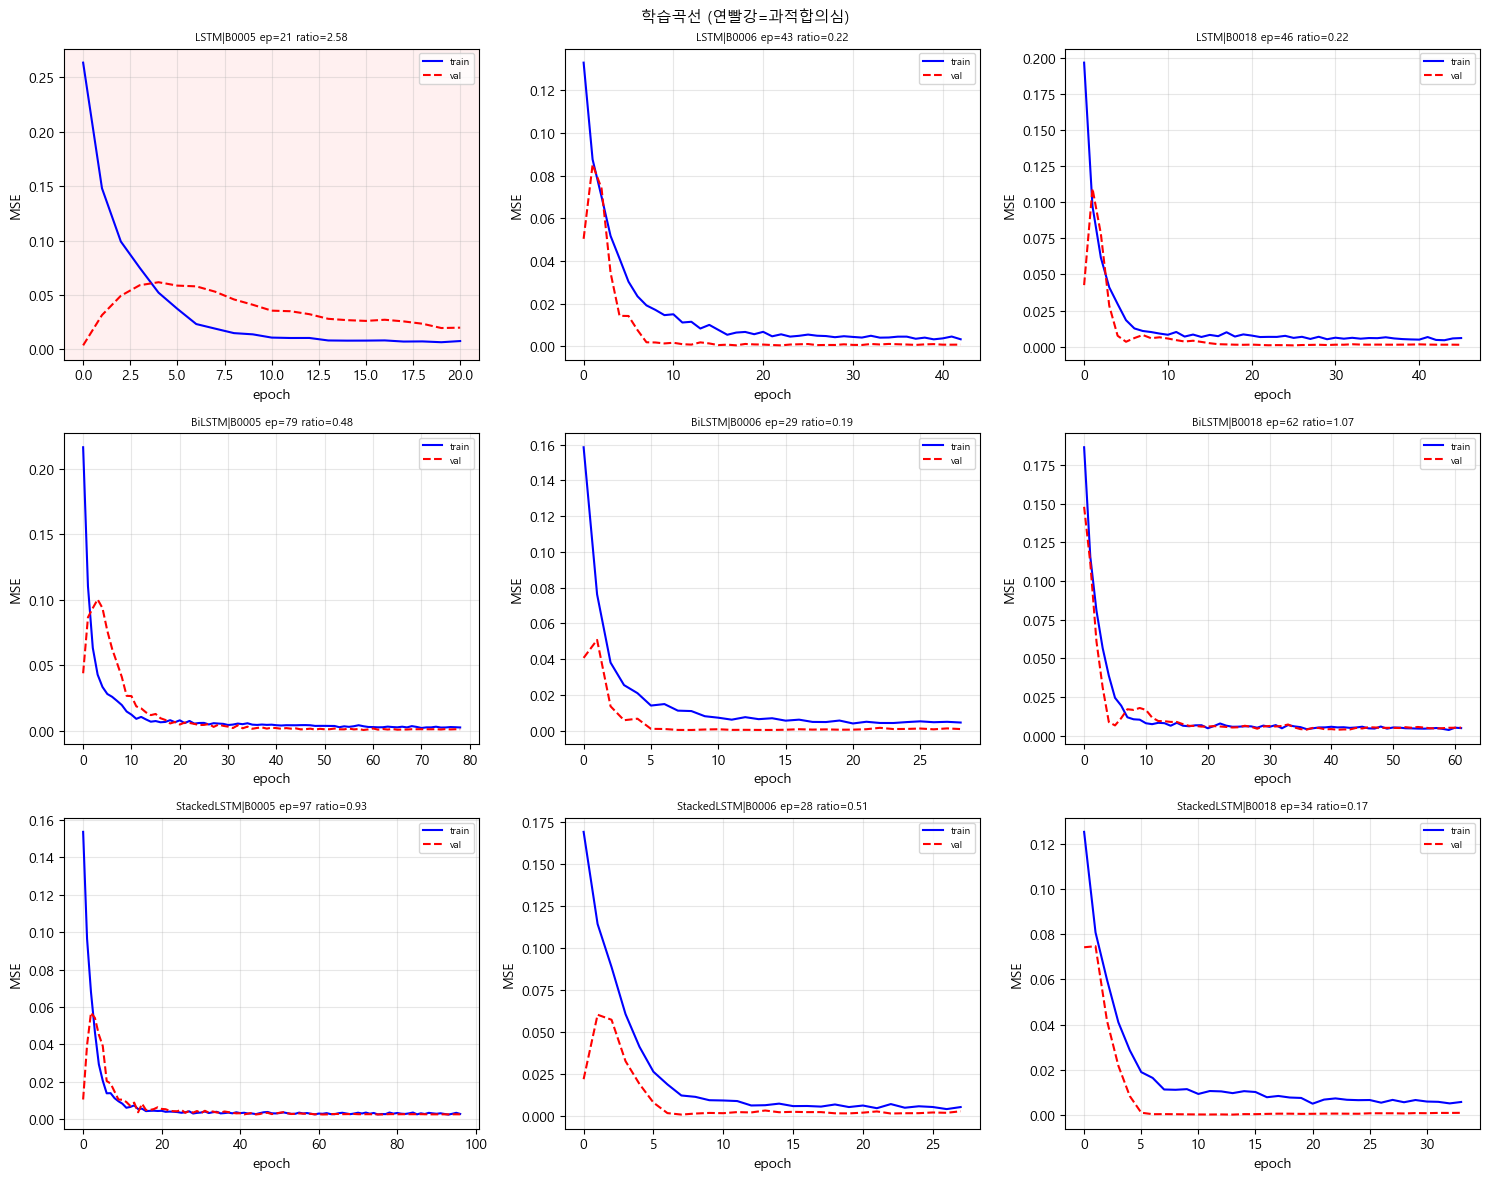

In [33]:
if not TF_OK or not LSTM_RESULTS:
    print('생략')
else:
    mnames = list(LSTM_RESULTS.keys())
    bats   = sorted(df_ml_rul['battery_id'].unique())
    fig, axes = plt.subplots(len(mnames), len(bats),
                              figsize=(5*len(bats), 4*len(mnames)))
    for row, mn in enumerate(mnames):
        for col, bat in enumerate(bats):
            ax = axes[row][col] if len(mnames)>1 else axes[col]
            h = next((x for x in LSTM_RESULTS[mn]['histories'] if x['battery']==bat),None)
            if h is None: ax.set_visible(False); continue
            hh = h['history']
            ax.plot(hh['loss'],'b-',lw=1.5,label='train')
            ax.plot(hh['val_loss'],'r--',lw=1.5,label='val')
            ratio = hh['val_loss'][-1]/hh['loss'][-1] if hh['loss'][-1]>0 else 0
            if ratio>2.5: ax.set_facecolor('#fff0f0')
            ax.set_title('%s|%s ep=%d ratio=%.2f'%(mn,bat,len(hh['loss']),ratio),fontsize=8)
            ax.set_xlabel('epoch'); ax.set_ylabel('MSE')
            ax.legend(fontsize=7); ax.grid(alpha=0.3)
    plt.suptitle('학습곡선 (연빨강=과적합의심)',fontsize=11)
    plt.tight_layout(); plt.show()


## Step 10. 단방향 vs 양방향 성능 비교


[중간 확인 11] 3종 LOBO 평균 성능
      model    MAE   RMSE     R2
       LSTM 24.432 29.975 -0.125
     BiLSTM 16.119 17.627  0.687
StackedLSTM 10.472 13.603  0.826

[중간 확인 12] 해석
  LSTM    29.98사이클
  BiLSTM  17.63사이클
  → BiLSTM이 12.35사이클 더 정확: 역방향 정보 기여
  배터리 3개 기반 → 통계적 단정 불가, 경향 파악이 목적


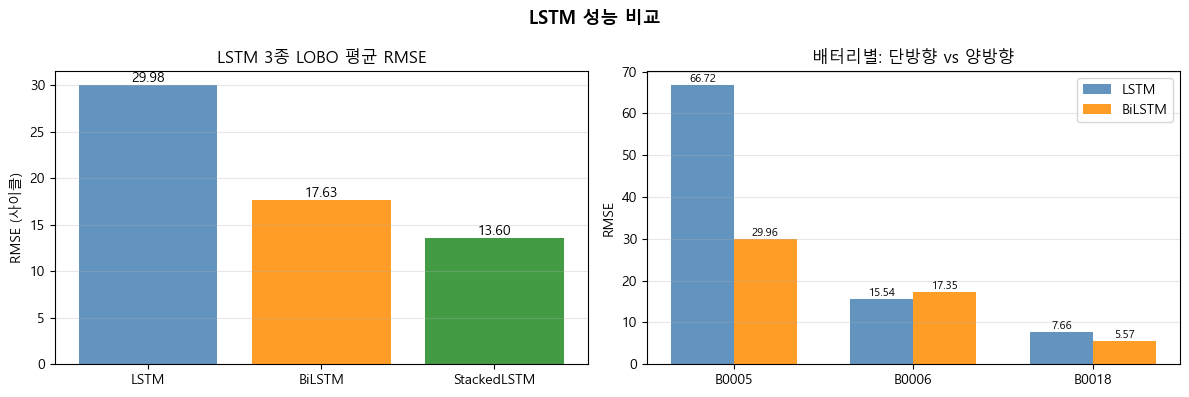

In [34]:
if not TF_OK or not LSTM_RESULTS:
    print('생략')
else:
    rows = []
    for mn, res in LSTM_RESULTS.items():
        r = {'model':mn}; r.update(res['mean'].iloc[0].to_dict()); rows.append(r)
    lstm_summary_df = pd.DataFrame(rows)

    print('[중간 확인 11] 3종 LOBO 평균 성능')
    print(lstm_summary_df[['model','MAE','RMSE','R2']].to_string(index=False))
    print()

    lr = LSTM_RESULTS['LSTM']['mean'].iloc[0]['RMSE']
    br = LSTM_RESULTS['BiLSTM']['mean'].iloc[0]['RMSE']
    diff = lr - br
    print('[중간 확인 12] 해석')
    print('  LSTM    %.2f사이클' % lr)
    print('  BiLSTM  %.2f사이클' % br)
    if abs(diff)<1.0:
        print('  → 차이(%.2f) 미미: 단방향으로 충분' % diff)
    elif diff>0:
        print('  → BiLSTM이 %.2f사이클 더 정확: 역방향 정보 기여' % diff)
    else:
        print('  → LSTM이 %.2f사이클 더 정확: 데이터 부족으로 양방향 과적합' % (-diff))
    print('  배터리 3개 기반 → 통계적 단정 불가, 경향 파악이 목적')

    colors = {'LSTM':'steelblue','BiLSTM':'darkorange','StackedLSTM':'forestgreen'}
    fig, axes = plt.subplots(1,2,figsize=(12,4))
    ax = axes[0]
    bars = ax.bar(lstm_summary_df['model'], lstm_summary_df['RMSE'],
                  color=[colors.get(m,'gray') for m in lstm_summary_df['model']], alpha=0.85)
    ax.bar_label(bars, fmt='%.2f', fontsize=10)
    ax.set_title('LSTM 3종 LOBO 평균 RMSE'); ax.set_ylabel('RMSE (사이클)'); ax.grid(axis='y',alpha=0.3)
    ax = axes[1]
    ld = LSTM_RESULTS['LSTM']['detail']; bd = LSTM_RESULTS['BiLSTM']['detail']
    blist = ld['held_out'].tolist(); x=np.arange(len(blist)); w=0.35
    b1=ax.bar(x-w/2,ld['RMSE'],width=w,label='LSTM',color='steelblue',alpha=0.85)
    b2=ax.bar(x+w/2,bd['RMSE'],width=w,label='BiLSTM',color='darkorange',alpha=0.85)
    ax.bar_label(b1,fmt='%.2f',fontsize=8); ax.bar_label(b2,fmt='%.2f',fontsize=8)
    ax.set_xticks(x); ax.set_xticklabels(blist)
    ax.set_title('배터리별: 단방향 vs 양방향'); ax.set_ylabel('RMSE')
    ax.legend(); ax.grid(axis='y',alpha=0.3)
    plt.suptitle('LSTM 성능 비교',fontsize=13,fontweight='bold')
    plt.tight_layout(); plt.show()


## Step 11. 예측 vs 실제 시각화


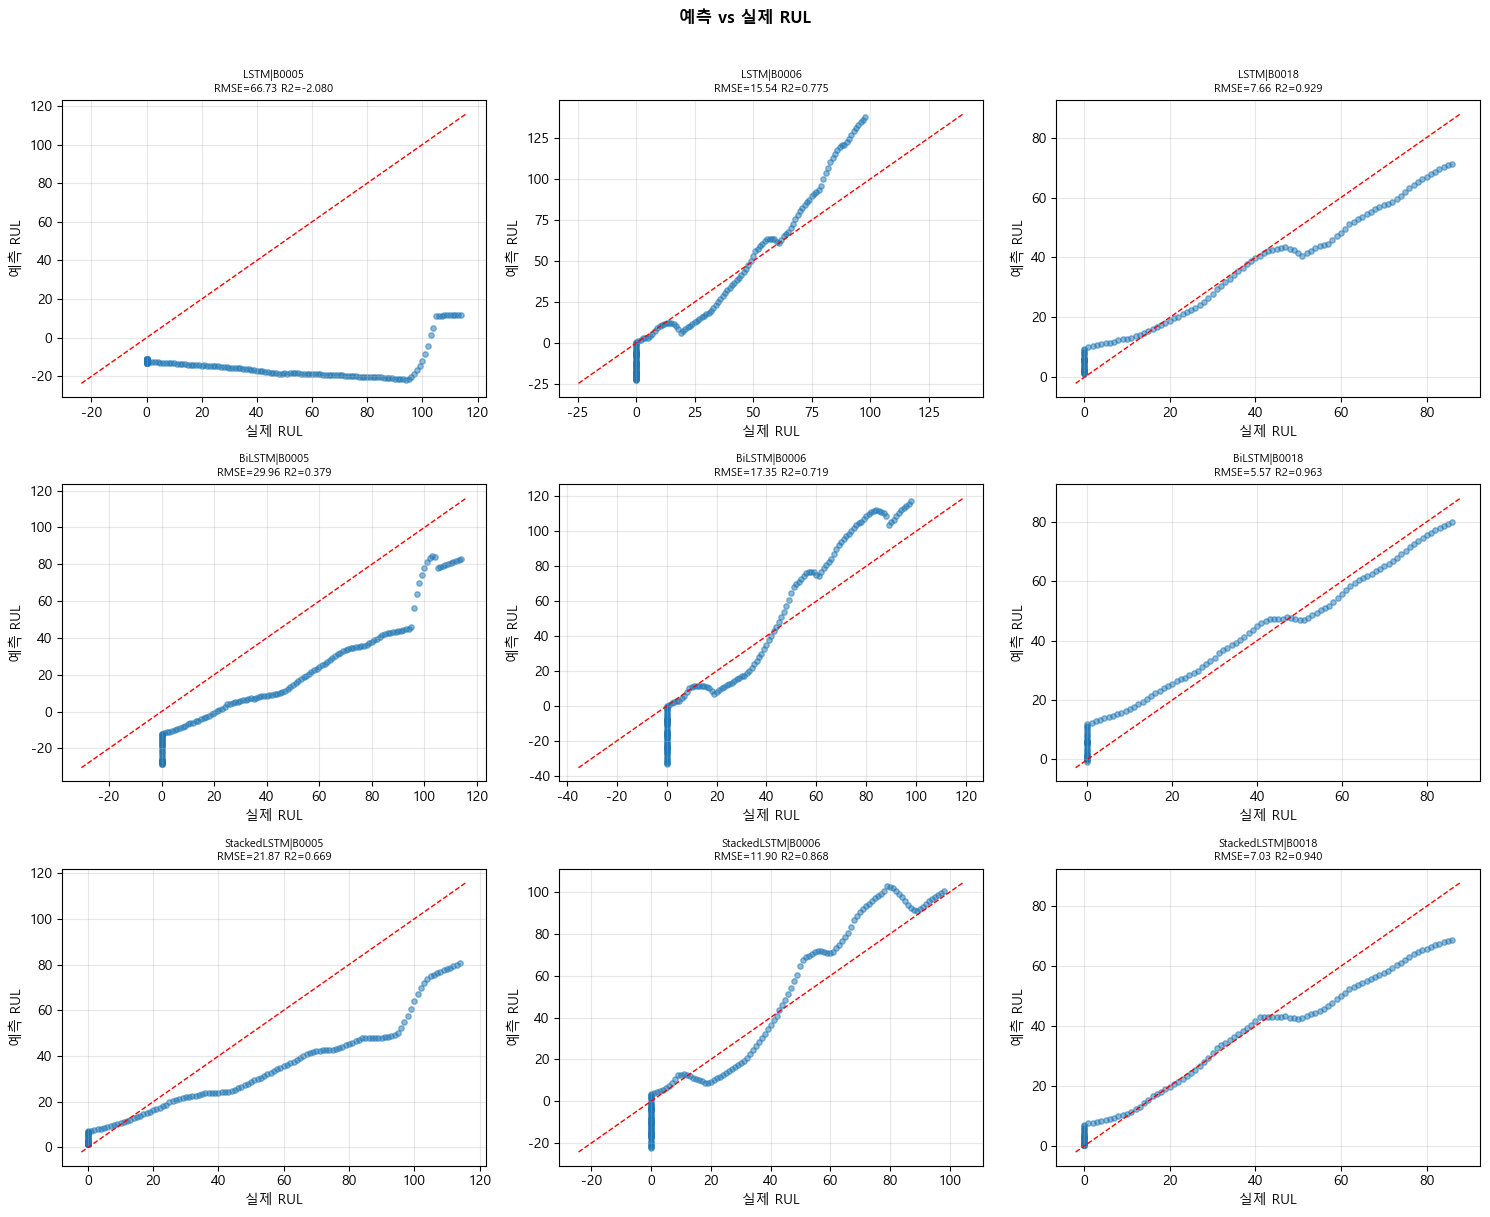

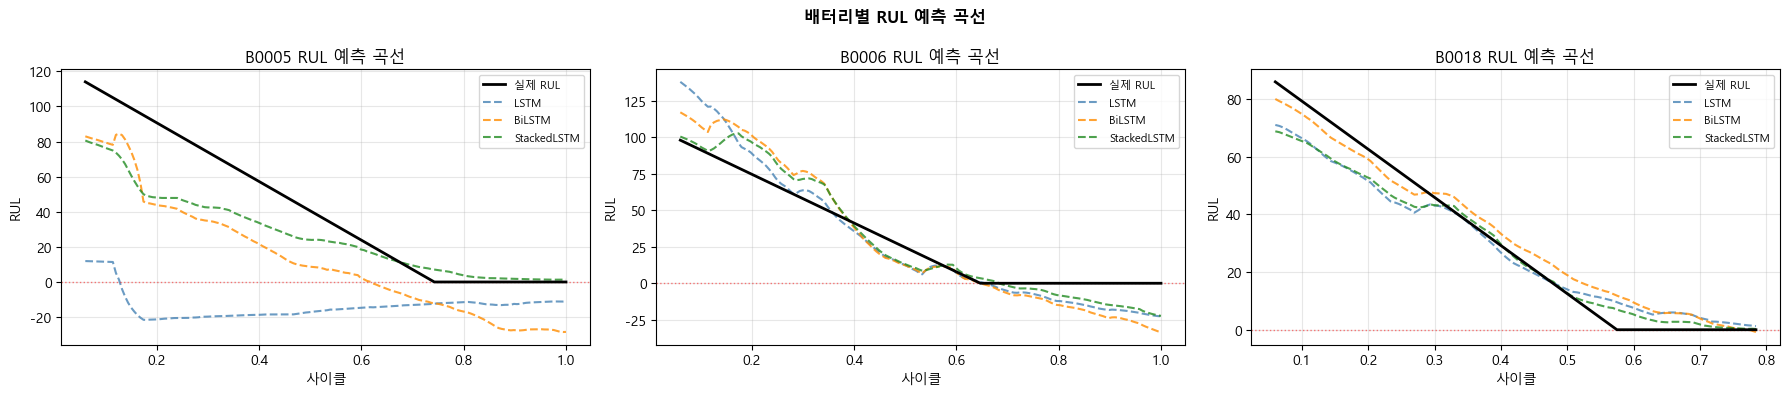

In [35]:
if not TF_OK or not LSTM_RESULTS:
    print('생략')
else:
    mnames = list(LSTM_RESULTS.keys())
    bats   = sorted(df_ml_rul['battery_id'].unique())
    fig, axes = plt.subplots(len(mnames),len(bats),figsize=(5*len(bats),4*len(mnames)))
    for row, mn in enumerate(mnames):
        preds = LSTM_RESULTS[mn]['all_preds']
        for col, bat in enumerate(bats):
            ax = axes[row][col] if len(mnames)>1 else axes[col]
            bp = preds[preds['battery_id']==bat]
            if len(bp)==0: ax.set_visible(False); continue
            yt=bp['RUL_true']; yp=bp['y_pred']
            ax.scatter(yt,yp,alpha=0.5,s=15)
            lo=min(yt.min(),yp.min())-2; hi=max(yt.max(),yp.max())+2
            ax.plot([lo,hi],[lo,hi],'r--',lw=1)
            rmse=mean_squared_error(yt,yp)**0.5; r2=r2_score(yt,yp)
            ax.set_title('%s|%s\nRMSE=%.2f R2=%.3f'%(mn,bat,rmse,r2),fontsize=8)
            ax.set_xlabel('실제 RUL'); ax.set_ylabel('예측 RUL'); ax.grid(alpha=0.3)
    plt.suptitle('예측 vs 실제 RUL',fontsize=12,fontweight='bold',y=1.01)
    plt.tight_layout(); plt.show()

    # 사이클 흐름
    cmap = {'LSTM':'steelblue','BiLSTM':'darkorange','StackedLSTM':'forestgreen'}
    fig, axes = plt.subplots(1,len(bats),figsize=(6*len(bats),4))
    for col, bat in enumerate(bats):
        ax = axes[col] if len(bats)>1 else axes
        ref = LSTM_RESULTS[mnames[0]]['all_preds']
        br  = ref[ref['battery_id']==bat].sort_values('cycle')
        if len(br)>0: ax.plot(br['cycle'],br['RUL_true'],'k-',lw=2,label='실제 RUL',zorder=10)
        for mn in mnames:
            bp = LSTM_RESULTS[mn]['all_preds']
            bp = bp[bp['battery_id']==bat].sort_values('cycle')
            if len(bp)>0:
                ax.plot(bp['cycle'],bp['y_pred'],'--',lw=1.5,alpha=0.8,
                        color=cmap.get(mn,'gray'),label=mn)
        ax.axhline(0,color='red',lw=1,ls=':',alpha=0.5)
        ax.set_title('%s RUL 예측 곡선'%bat); ax.set_xlabel('사이클'); ax.set_ylabel('RUL')
        ax.legend(fontsize=8); ax.grid(alpha=0.3)
    plt.suptitle('배터리별 RUL 예측 곡선',fontsize=12,fontweight='bold')
    plt.tight_layout(); plt.show()


## Step 12. pre-EOL 성능 분리

RUL=0 행이 RMSE를 낮춰 보이게 만들 수 있음. RUL>0만 따로 평가.


In [36]:
if not TF_OK or not LSTM_RESULTS:
    print('생략')
else:
    print('[중간 확인 13] pre-EOL 분리 평가')
    rows = []
    for mn, res in LSTM_RESULTS.items():
        preds = res['all_preds']
        if len(preds)==0: continue
        m_all = calc_metrics(preds['RUL_true'],preds['y_pred'],'전체')
        pe    = preds[preds['RUL_true']>0]
        m_pe  = calc_metrics(pe['RUL_true'],pe['y_pred'],'preEOL') if len(pe)>0 else {'RMSE':None,'R2':None}
        inflated = m_all['RMSE'] < (m_pe['RMSE'] or 0)
        rows.append({'model':mn,
                     'RMSE_전체':m_all['RMSE'],'RMSE_preEOL':m_pe['RMSE'],
                     'R2_전체':m_all['R2'],'R2_preEOL':m_pe['R2'],
                     'n_preEOL':len(pe),
                     '부풀림':('부풀려짐' if inflated else '정상')})
    df_pe = pd.DataFrame(rows)
    print(df_pe.to_string(index=False))
    print()
    print('RMSE_preEOL > RMSE_전체 → RUL=0 행이 성능을 낮춰 보이게 함')
    print('진짜 예측력은 preEOL 수치로 판단')


[중간 확인 13] pre-EOL 분리 평가
      model  RMSE_전체  RMSE_preEOL  R2_전체  R2_preEOL  n_preEOL  부풀림
       LSTM   41.347       49.471 -0.466     -1.755       298 부풀려짐
     BiLSTM   21.002       22.181  0.622      0.446       298 부풀려짐
StackedLSTM   15.409       17.835  0.796      0.642       298 부풀려짐

RMSE_preEOL > RMSE_전체 → RUL=0 행이 성능을 낮춰 보이게 함
진짜 예측력은 preEOL 수치로 판단


## Step 13. 종합 해석



왜 LSTM인가
  EDA에서 두 가지 열화 패턴 발견
  후반 가속형(B0005/B0007) vs 처음부터 빠른형(B0006/B0018)
  XGBoost: 각 사이클 독립 처리 → 패턴 흐름 기억 못함
  LSTM: 10사이클 시퀀스 학습 → 열화 속도와 패턴 구분

단방향 vs 양방향
  LSTM   12.08사이클
  BiLSTM 15.82사이클
  LSTM이 3.74사이클 더 정확 → 데이터 부족으로 양방향 과적합

한계
  학습 배터리 3개 → 일반화 불확실
  window=10 → 초반 10사이클 예측 불가
  데이터 더 많으면 성능 개선 여지 있음

## Step 14. 결과 저장


In [37]:
if TF_OK and LSTM_RESULTS:
    save_dir = base_path if 'base_path' in dir() else 'data'
    os.makedirs(save_dir, exist_ok=True)
    if 'lstm_summary_df' in dir():
        lstm_summary_df.to_csv(os.path.join(save_dir,'ml_lstm_summary.csv'),index=False)
    for mn, res in LSTM_RESULTS.items():
        if len(res['all_preds'])>0:
            res['all_preds'].to_csv(
                os.path.join(save_dir,'ml_lstm_%s_pred.csv'%mn.lower()),index=False)
    print('저장 완료:', save_dir)
else:
    print('학습 미완료')


저장 완료: data
